In [53]:
import numpy as np
import matplotlib.pyplot as plt
import os
import torch
import slicetca

# import utils as ut
# import plot as pt
plt.rcParams.update({'font.size': 12,
                     'axes.spines.right': False,
                     'axes.spines.top':   False,
                     'legend.frameon':    False,})

%load_ext autoreload
%autoreload 2


import sys
from scipy.stats import sem
sys.path.append('/Users/michaelfinch/CA1-interneuron-GLM')

from utils_TCA_clustering_scratchpad import *
from GLM_regression_plotting import *


from modelling_to_date_utils import *
from SliceTCA_example import *


GLM_params_SST, activity_dict_SST, double_predicted_activity_dict_SST, factors_dict_SST, filtered_factors_dict_SST, residual_activity_dict_SST = load_data_regular(file_path='/Users/michaelfinch/CA1-interneuron-GLM', name="SSTindivsomata_GLM", new_NDNF=False)
GLM_params_EC, activity_dict_EC, double_predicted_activity_dict_EC, factors_dict_EC, filtered_factors_dict_EC, residual_activity_dict_EC = load_data_regular(file_path='/Users/michaelfinch/CA1-interneuron-GLM', name="EC_GLM", new_NDNF=False)


GLM_params_NDNF_newest, activity_dict_NDNF_newest, double_predicted_activity_dict_NDNF_newest, factors_dict_NDNF_newest, filtered_factors_dict_NDNF_newest, residual_activity_dict_NDNF_newest = load_data_regular(file_path='/Users/michaelfinch/CA1-interneuron-GLM', name="NDNF_E1A1B", new_NDNF=True)

fixed_residual_activity_dict_NDNF_newest = {}
for idx, animal in enumerate(residual_activity_dict_NDNF_newest):
    if 17 < idx < 31:
        fixed_residual_activity_dict_NDNF_newest[f"animal_{idx+1}"] = residual_activity_dict_NDNF_newest[animal]

fixed_activity_dict_NDNF_newest = {}
for idx, animal in enumerate(activity_dict_NDNF_newest):
    if 17 < idx < 31:
        fixed_activity_dict_NDNF_newest[f"animal_{idx+1}"] = activity_dict_NDNF_newest[animal]

fixed_filtered_factors_dict_NDNF_newest = {}
for idx, animal in enumerate(filtered_factors_dict_NDNF_newest):
    if 17 < idx < 31:
        fixed_filtered_factors_dict_NDNF_newest[f"animal_{idx+1}"] = filtered_factors_dict_NDNF_newest[animal]


fixed_factors_dict_NDNF_newest = {}
for idx, animal in enumerate(factors_dict_NDNF_newest):
    if 17 < idx < 31:
        fixed_factors_dict_NDNF_newest[f"animal_{idx+1}"] = factors_dict_NDNF_newest[animal]



The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [ ]:
# def get_r_list(fixed_activity_dict_NDNF_newest, factors_dict_NDNF_newest, data_to_corr=None):

#     r_list_vel = []
#     vel_per_animal = []
#     for animal in fixed_activity_dict_NDNF_newest:
#         for cell in fixed_activity_dict_NDNF_newest[animal]:
#             vel = factors_dict_NDNF_newest[animal][data_to_corr][:,:100]
#             vel_per_animal.append(vel)
#             data = fixed_activity_dict_NDNF_newest[animal][cell][:,:100]
#             r, _ = pearsonr(vel.flatten(), data.flatten())
#             r_list_vel.append(r)

#     array_data = np.array(vel_per_animal)
#     r_dict_vel = {"r_list":r_list_vel,
#                   "array_data":array_data}

#     return r_dict_vel


r_dict_vel = get_r_list(fixed_activity_dict_NDNF_newest, factors_dict_NDNF_newest, data_to_corr="Velocity")
r_dict_licks = get_r_list(fixed_activity_dict_NDNF_newest, factors_dict_NDNF_newest, data_to_corr="Licks")
            

r_dict_vel_resid = get_r_list(fixed_residual_activity_dict_NDNF_newest, factors_dict_NDNF_newest, data_to_corr="Velocity")
r_dict_licks_resid = get_r_list(fixed_residual_activity_dict_NDNF_newest, factors_dict_NDNF_newest, data_to_corr="Licks")



In [ ]:
cells_per_animal_dict = {}

count=0
for animal in fixed_activity_dict_NDNF_newest:
    per_animal_list=[]
    for cell in fixed_activity_dict_NDNF_newest[animal]:
        per_animal_list.append(count)
        count+=1
    cells_per_animal_dict[animal] = per_animal_list




[26, 27, 28, 29, 30, 31, 32, 33]


In [ ]:
# def get_truncated_to_min_data_array(fixed_activity_dict_NDNF_newest):
#     min_val = 10000

#     for animal in fixed_activity_dict_NDNF_newest:
#         for cell in fixed_activity_dict_NDNF_newest[animal]:
#             data = fixed_activity_dict_NDNF_newest[animal][cell]
#             if data.shape[1] < min_val:
#                 min_val = data.shape[1]

#     data_truncated_list = []
#     for animal in fixed_activity_dict_NDNF_newest:
#         for cell in fixed_activity_dict_NDNF_newest[animal]:
#             data_truncated = fixed_activity_dict_NDNF_newest[animal][cell][:,:min_val]
#             data_truncated_list.append(data_truncated)


#     data_truncated_array = np.array(data_truncated_list)

#     return data_truncated_array

In [6]:
data_truncated_array_NDNF = get_truncated_to_min_data_array(fixed_residual_activity_dict_NDNF_newest)
example_NDNF_cell_tensor = torch.from_numpy(data_truncated_array_NDNF)
example_NDNF_cell_tensor = example_NDNF_cell_tensor.permute(2,0,1)
print(example_NDNF_cell_tensor.shape)

torch.Size([100, 115, 50])


Loss: 0.4978232148096947 : 100%|██████████| 4000/4000 [03:41<00:00, 18.07it/s] 


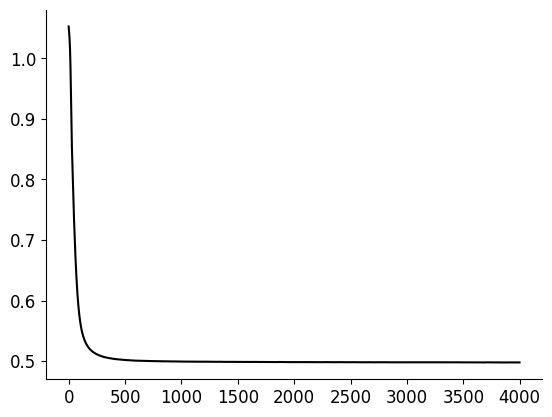

Loss: 0.45524510661071405 : 100%|██████████| 4000/4000 [04:04<00:00, 16.36it/s]


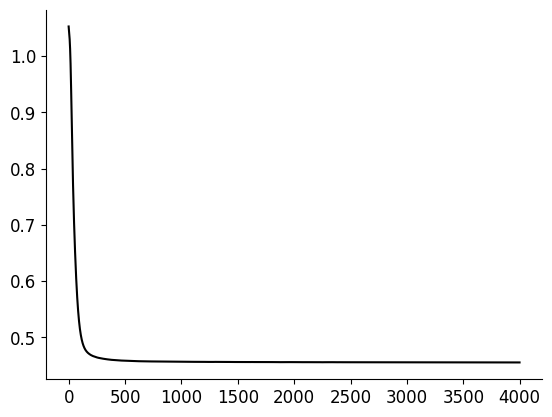

Loss: 0.08943692882815432 : 100%|██████████| 4000/4000 [03:57<00:00, 16.86it/s]


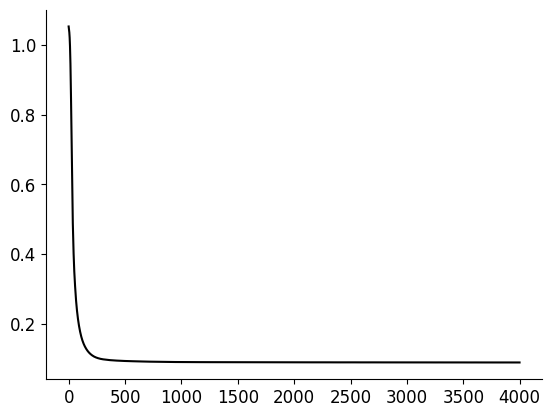

In [ ]:

# def get_the_tca_model(fixed_residual_activity_dict_NDNF_newest, components=None):
#     data_truncated_array_NDNF = get_truncated_to_min_data_array(fixed_residual_activity_dict_NDNF_newest)
#     example_NDNF_cell_tensor = torch.from_numpy(data_truncated_array_NDNF)
#     example_NDNF_cell_tensor = example_NDNF_cell_tensor.permute(2,0,1)

        
#     components_10, model_20_NDNF_resid = slicetca.decompose(example_NDNF_cell_tensor,
#                                                 number_components=components, # (trials, neurons, time bins)
#                                                 positive=False,learning_rate=1*10**-2, min_std=10**-5, max_iter=4000, iter_std=1000,seed=0)

#     plt.plot(model_20_NDNF_resid.losses, color='k')
#     plt.show()

#     return model_20_NDNF_resid


model_20_NDNF_raw_x00 = get_the_tca_model(fixed_activity_dict_NDNF_newest, components=(20,0,0))
model_20_NDNF_raw_0x0 = get_the_tca_model(fixed_activity_dict_NDNF_newest, components=(0,20,0))
model_20_NDNF_raw_00x = get_the_tca_model(fixed_activity_dict_NDNF_newest, components=(0,0,20))


Loss: 0.457597679210631 : 100%|██████████| 4000/4000 [03:17<00:00, 20.23it/s]  


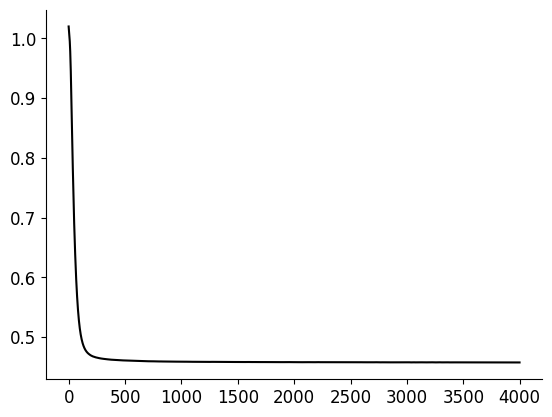

Loss: 0.5054261888512998 : 100%|██████████| 4000/4000 [03:18<00:00, 20.18it/s]


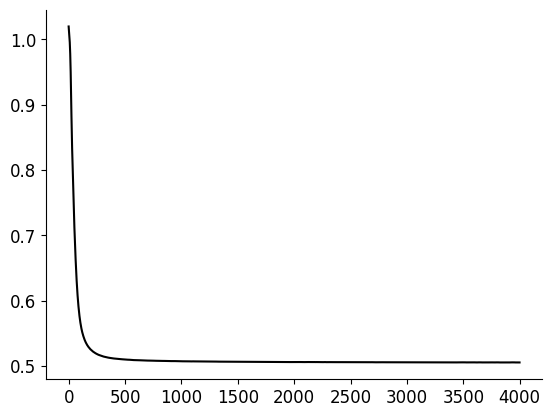

Loss: 0.09161994989468654 : 100%|██████████| 4000/4000 [03:55<00:00, 16.97it/s]


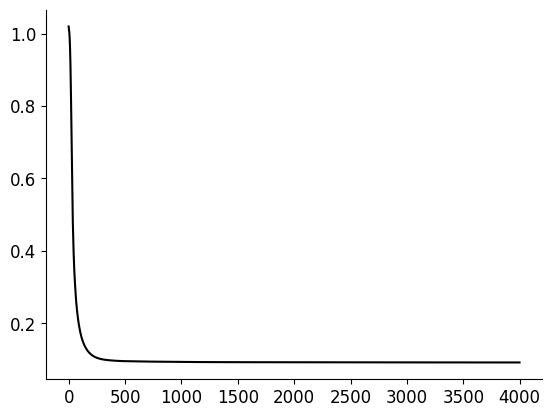

In [8]:
model_20_NDNF_resid_0x0 = get_the_tca_model(fixed_residual_activity_dict_NDNF_newest, components=(0,20,0))
model_20_NDNF_resid_x00 = get_the_tca_model(fixed_residual_activity_dict_NDNF_newest, components=(20,0,0))
model_20_NDNF_resid_00x = get_the_tca_model(fixed_residual_activity_dict_NDNF_newest, components=(0,0,20))

In [10]:
important_dict = {"model_20_NDNF_resid_0x0":model_20_NDNF_resid_0x0,
                  "model_20_NDNF_resid_x00":model_20_NDNF_resid_x00,
                  "model_20_NDNF_resid_00x":model_20_NDNF_resid_00x,
                  "model_20_NDNF_raw_x00":model_20_NDNF_raw_x00,
                  "model_20_NDNF_raw_x00":model_20_NDNF_raw_x00,
                  "model_20_NDNF_raw_x00":model_20_NDNF_raw_x00
    
}

In [11]:
save_path="/Users/michaelfinch/CA1-interneuron-GLM/Clean_notebooks_to_date/pickle_every_slice_type_NDNF.pkl"
with open(save_path, 'wb') as f:
    pickle.dump(important_dict, f)

In [ ]:
# def get_labels_all_different_Ks_single(model_20_NDNF_resid, which_vectors: int):
#     from sklearn.cluster import KMeans
#     from sklearn.preprocessing import StandardScaler

#     w1 = model_20_NDNF_resid.vectors[which_vectors][0]
#     f1 = model_20_NDNF_resid.vectors[which_vectors][1]
#     F = f1.detach().cpu().numpy()   # (latents, cells, pos) = (20, 115, 50)
#     W = w1.detach().cpu().numpy()   # (latents, trials) = (20, 100)

#     print(f"F.shape {F.shape}  W.shape {W.shape}")

#     # Build X so rows = cells (115)
#     if which_vectors == 0:
#         # Use latent×pos per cell, flattened: (115, 20*50)
#         X = np.moveaxis(F, 1, 0)              # (cells=115, latents=20, pos=50)
#         X = X.reshape(X.shape[0], -1)         # (115, 1000)
#         print("X shape (latent×pos flat):", X.shape)

#     elif which_vectors == 1:
#         X = W.T  # (115, 20) mean over pos
#         print("X shape (mean over pos):", X.shape)

#     else:
#         X = np.moveaxis(F, 2, 0)     # -> (cells=115, latents=20, trials=100)
#         X = X.reshape(X.shape[0], -1)  # -> (115, 20*100) = (115, 2000)
#         print(X.shape)  # (115, 2000)

#     # Standardize then KMeans over K=1..10
#     Xz = StandardScaler().fit_transform(X)
#     labels_cells_dict_all_K = {K: KMeans(n_clusters=K, n_init=100, random_state=42).fit_predict(Xz) for K in range(1, 11)}
#     return labels_cells_dict_all_K


labels_cells_dict_all_K_NDNF_x00_raw = get_labels_all_different_Ks_single(model_20_NDNF_raw_x00, which_vectors=0)


F.shape (20, 115, 50)  W.shape (20, 100)
X shape (latent×pos flat): (115, 1000)


In [15]:
labels_cells_dict_all_K_NDNF_0x0_raw = get_labels_all_different_Ks_single(model_20_NDNF_raw_0x0, which_vectors=1)

F.shape (20, 100, 50)  W.shape (20, 115)
X shape (mean over pos): (115, 20)


In [16]:
labels_cells_dict_all_K_NDNF_00x_raw = get_labels_all_different_Ks_single(model_20_NDNF_raw_00x, which_vectors=2)

F.shape (20, 100, 115)  W.shape (20, 50)
(115, 2000)


In [21]:
labels_cells_dict_all_K_NDNF_x00_resid = get_labels_all_different_Ks_single(model_20_NDNF_resid_x00, which_vectors=0)

labels_cells_dict_all_K_NDNF_0x0_resid = get_labels_all_different_Ks_single(model_20_NDNF_resid_0x0, which_vectors=1)

labels_cells_dict_all_K_NDNF_00x_resid = get_labels_all_different_Ks_single(model_20_NDNF_resid_00x, which_vectors=2)

F.shape (20, 115, 50)  W.shape (20, 100)
X shape (latent×pos flat): (115, 1000)
F.shape (20, 100, 50)  W.shape (20, 115)
X shape (mean over pos): (115, 20)
F.shape (20, 100, 115)  W.shape (20, 50)
(115, 2000)


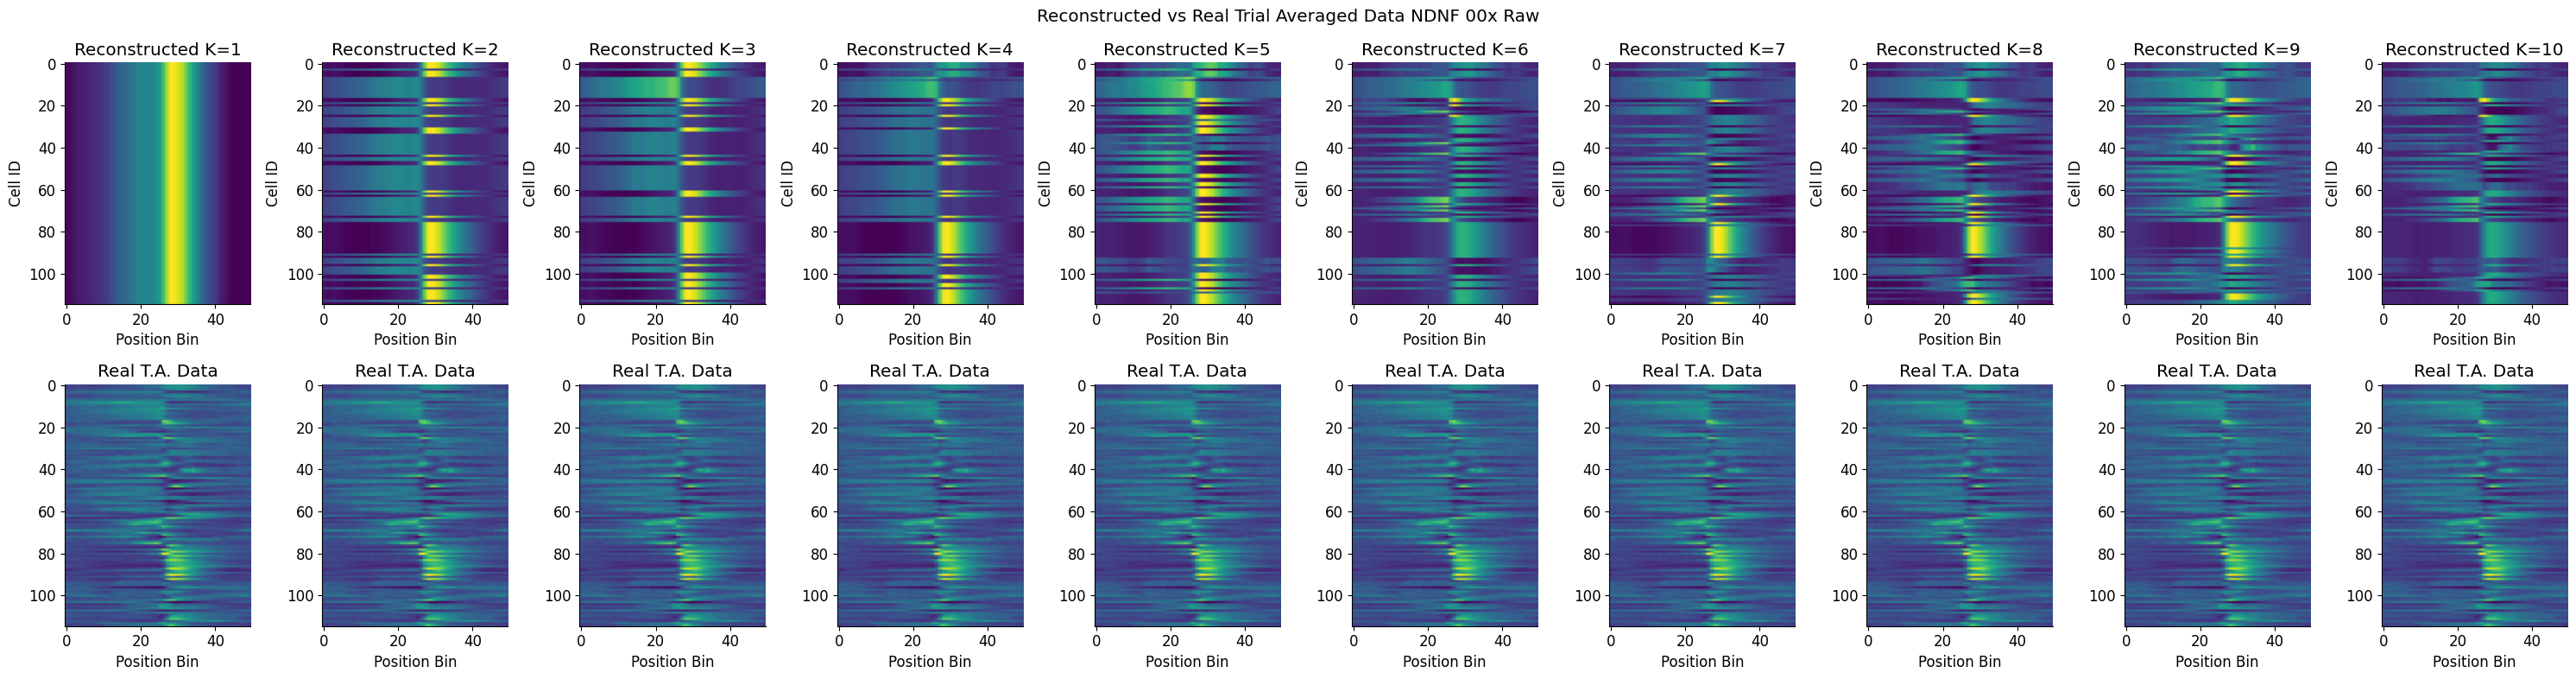

In [ ]:
# def plot_reconstructions(labels_cells_dict_all_K_NDNF, fixed_activity_dict_NDNF_newest, r_dict_vel, r_dict_licks, prefix=""):
#     synthetic_mean_array = {}
#     means_dict_cluster= {}
#     for num_clusters in labels_cells_dict_all_K_NDNF:
#         data_truncated_array_NDNF = get_truncated_to_min_data_array(fixed_activity_dict_NDNF_newest)
#         # print(data_truncated_array_NDNF.shape)
#         labels = labels_cells_dict_all_K_NDNF[num_clusters]
#         # print(labels)
#         uniq = np.unique(labels)
#         real_data_mean_array = np.empty(data_truncated_array_NDNF.shape)
#         mean_data_dict = {}

#         r_vel_dict_per_clust = {}
#         r_lick_dict_per_clust = {}

#         cell_ids_per_cluster_dict = {}

#         vel_data_sliced_dict = {}
#         lick_data_sliced_dict = {}

#         vel_array = r_dict_vel["array_data"]
#         lick_array = r_dict_licks["array_data"]

#         labels_loc_dict = {}

#         mean_data_list = []
#         fraction_cells_list = []
#         for i in uniq:
#             labels_loc = np.where(labels==i)[0]
#             cell_ids_per_cluster_dict[i] = labels_loc
#             fraction_cells = (len(labels_loc) / data_truncated_array_NDNF.shape[0])*100
#             fraction_cells_list.append(fraction_cells)
#             real_data_array_sliced = data_truncated_array_NDNF[labels_loc,:,:]
#             mean_real_data_array_sliced = np.mean(real_data_array_sliced, axis=0)
#             mean_data_list.append(mean_real_data_array_sliced)
#             real_data_mean_array[labels_loc,:,:] = mean_real_data_array_sliced

#             labels_loc_dict[i] = labels_loc
            
#             r_list_vel = np.array(r_dict_vel["r_list"])

#             r_list_licks = np.array(r_dict_licks["r_list"])

            

#             vel_data_sliced_dict[i] = vel_array[labels_loc,:,:]

#             lick_data_sliced_dict[i] = lick_array[labels_loc,:,:]

#             r_vel_dict_per_clust[i] = r_list_vel[labels_loc]
#             r_lick_dict_per_clust[i] = r_list_licks[labels_loc]



#         MSE_reco_vs_real = np.mean(np.square(data_truncated_array_NDNF-real_data_mean_array))

#         mean_data_dict = {"mean_data_list":mean_data_list,
#                         "fraction_cells":fraction_cells_list,
#                         "MSE_reco_vs_real":MSE_reco_vs_real,
#                         "r_vel_dict_per_clust":r_vel_dict_per_clust,
#                         "r_lick_dict_per_clust":r_lick_dict_per_clust,
#                         "cell_ids_per_cluster_dict":cell_ids_per_cluster_dict,
#                         "vel_data_sliced_dict":vel_data_sliced_dict,
#                         "lick_data_sliced_dict":lick_data_sliced_dict,
#                         "labels_loc_dict":labels_loc_dict}
        
#         means_dict_cluster[num_clusters] = mean_data_dict
#         synthetic_mean_array[num_clusters] = real_data_mean_array



#     data_truncated_array_NDNF = get_truncated_to_min_data_array(fixed_activity_dict_NDNF_newest)
#     data_truncated_array_NDNF_ta = np.mean(data_truncated_array_NDNF, axis=2)
#     fig, axs = plt.subplots(2,len(synthetic_mean_array), figsize=(30,8))
#     plt.suptitle(f"Reconstructed vs Real Trial Averaged Data {prefix}")
#     for num_clusters in synthetic_mean_array:
#         reconstructed_data = synthetic_mean_array[num_clusters]
#         reconstructed_data_ta = np.mean(reconstructed_data, axis=2)
#         axs[0,num_clusters-1].imshow(reconstructed_data_ta, aspect='auto')
#         axs[0,num_clusters-1].set_ylabel("Cell ID")
#         axs[0,num_clusters-1].set_title(f"Reconstructed K={num_clusters}")
#         axs[0,num_clusters-1].set_xlabel("Position Bin")
#         axs[1,num_clusters-1].imshow(data_truncated_array_NDNF_ta, aspect='auto')
#         axs[1,num_clusters-1].set_title("Real T.A. Data")
#         axs[1,num_clusters-1].set_xlabel("Position Bin")
#     plt.tight_layout()
#     plt.show()

#     return means_dict_cluster


means_dict_cluster_00x_raw = plot_reconstructions(labels_cells_dict_all_K_NDNF_00x_raw, fixed_activity_dict_NDNF_newest, r_dict_vel, r_dict_licks, prefix="NDNF 00x Raw")


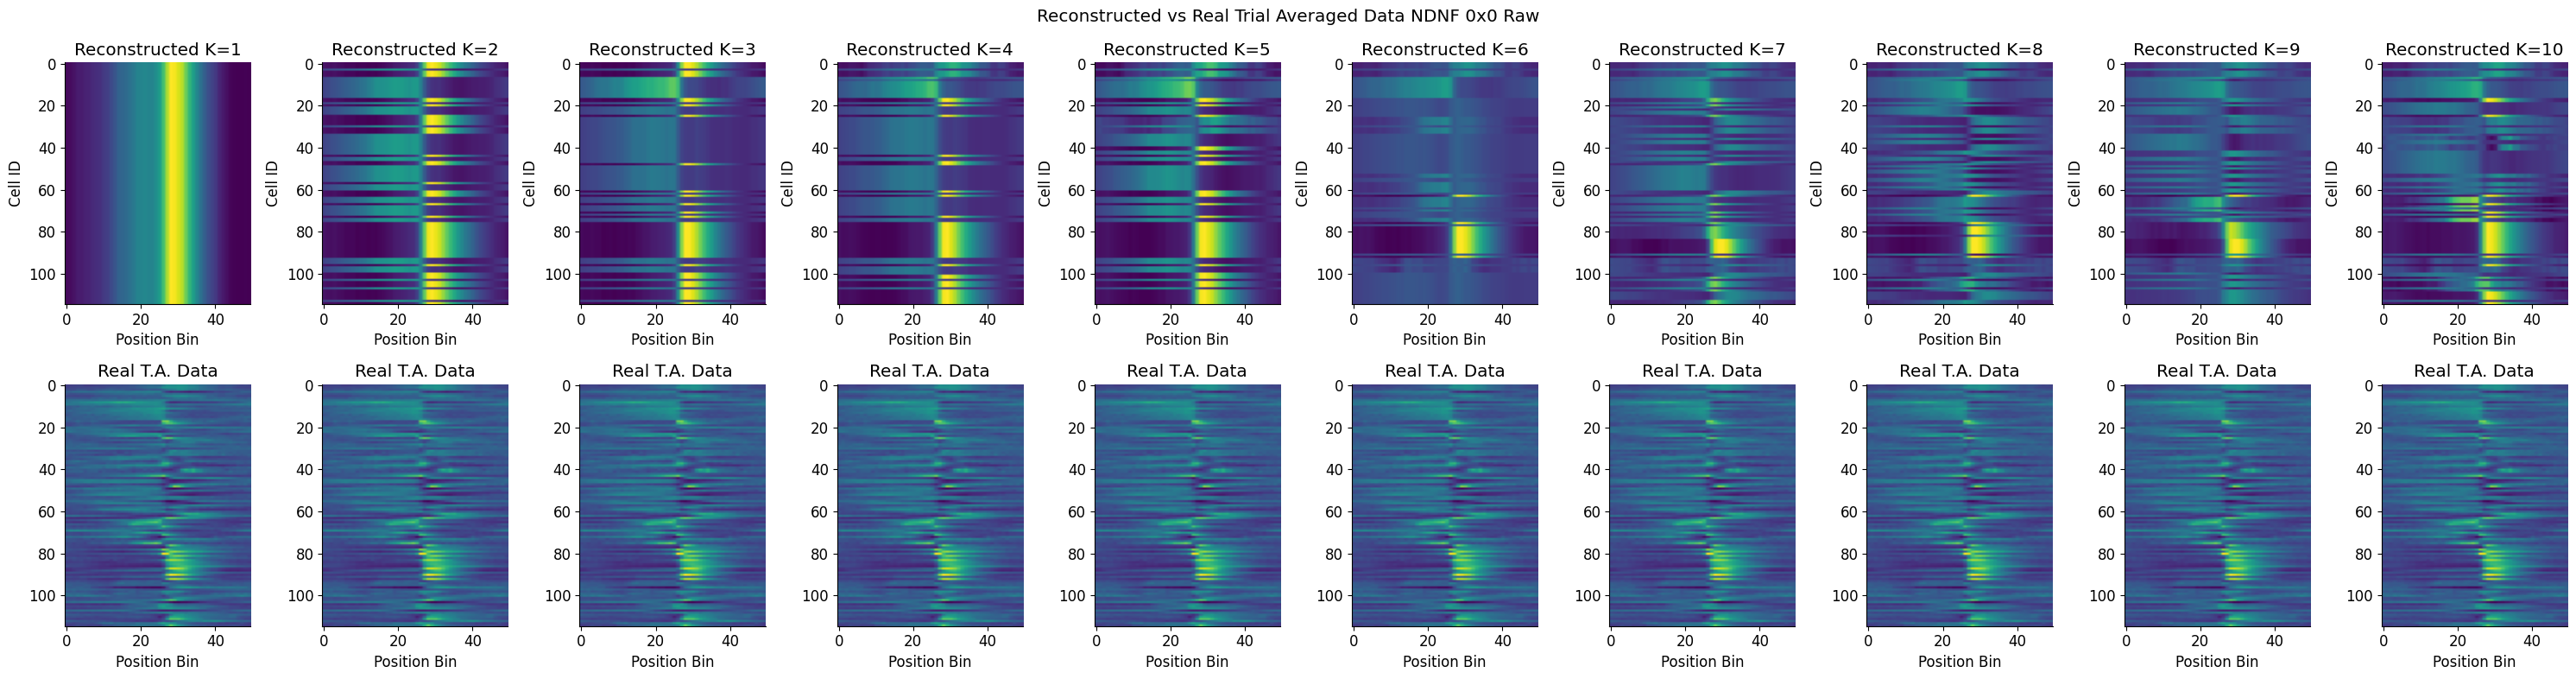

In [181]:
means_dict_cluster_0x0_raw = plot_reconstructions(labels_cells_dict_all_K_NDNF_0x0_raw, fixed_activity_dict_NDNF_newest, r_dict_vel, r_dict_licks, prefix="NDNF 0x0 Raw")

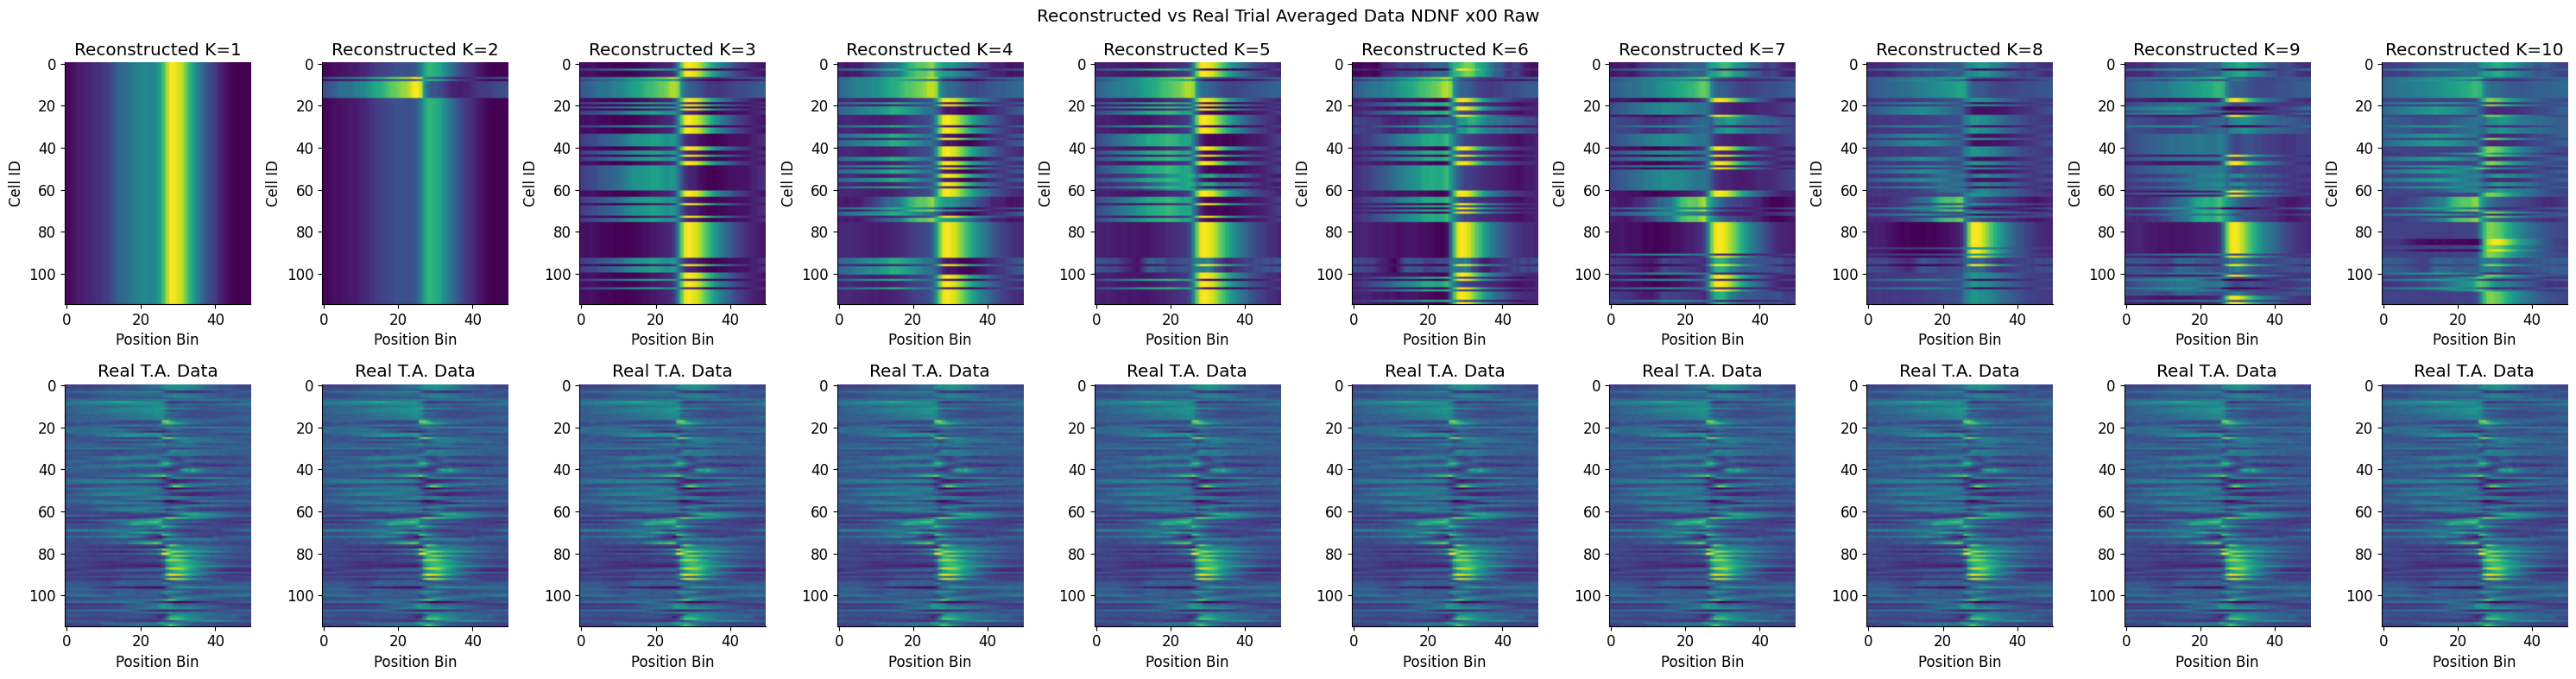

In [183]:
means_dict_cluster_x00_raw = plot_reconstructions(labels_cells_dict_all_K_NDNF_x00_raw, fixed_activity_dict_NDNF_newest, r_dict_vel, r_dict_licks, prefix="NDNF x00 Raw")

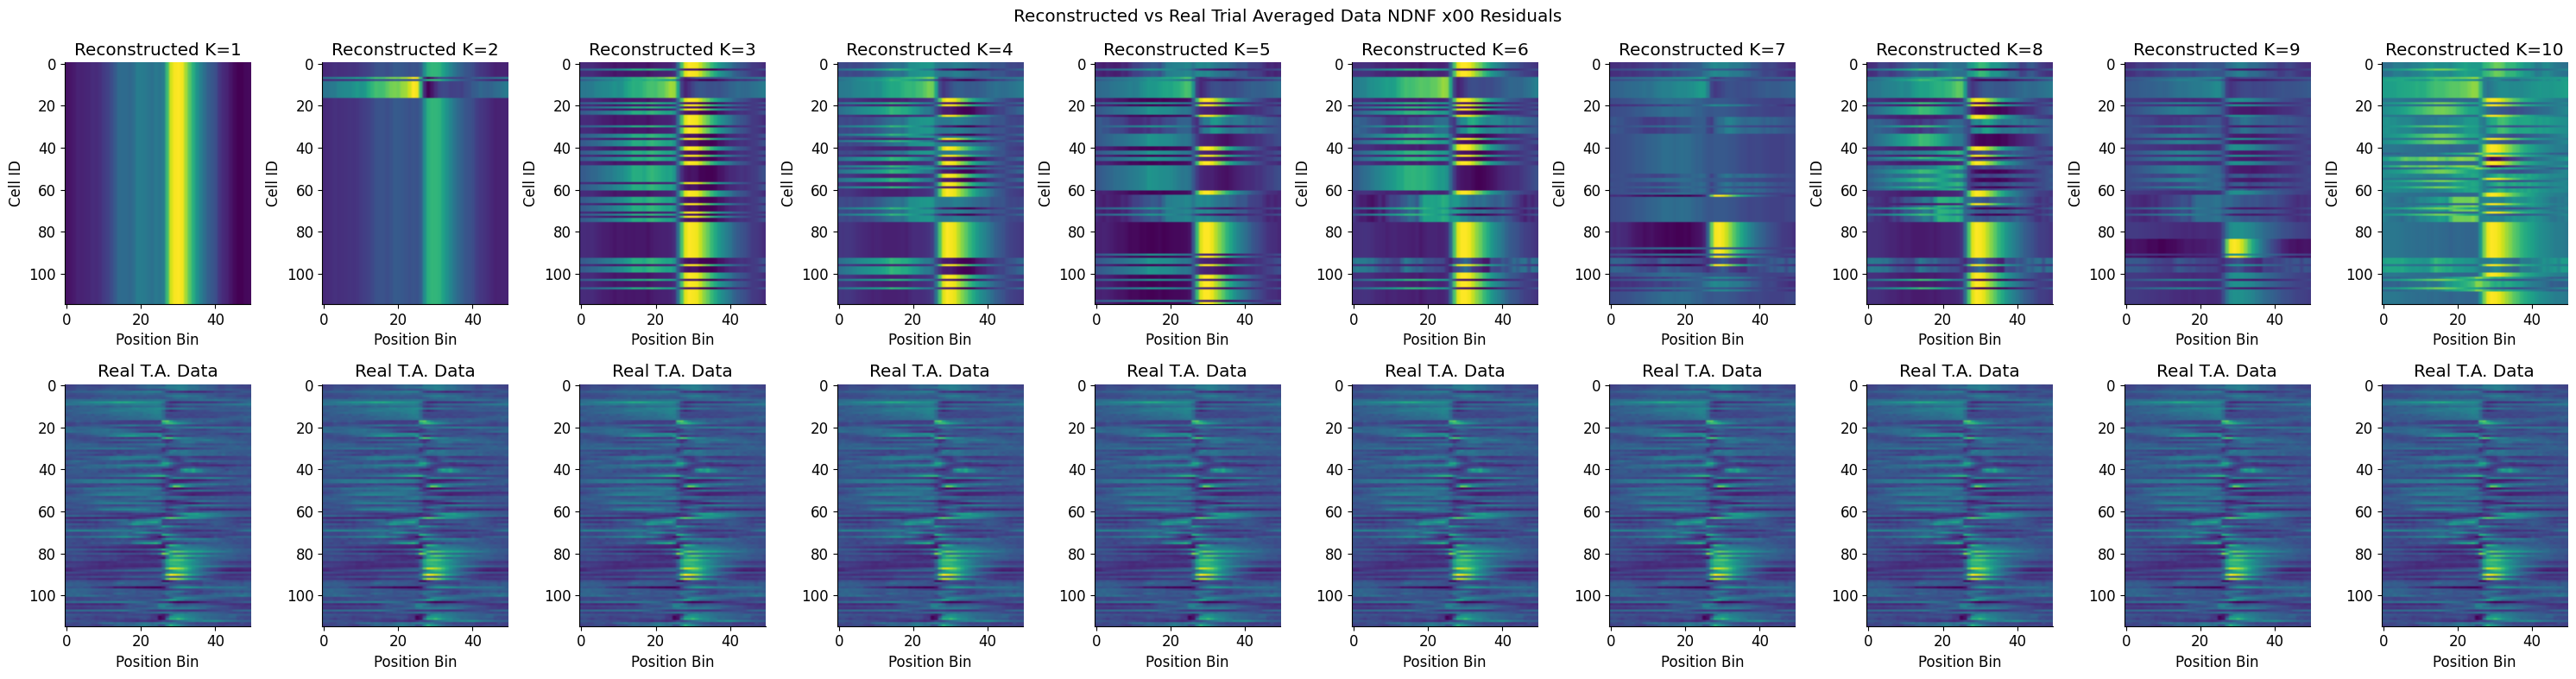

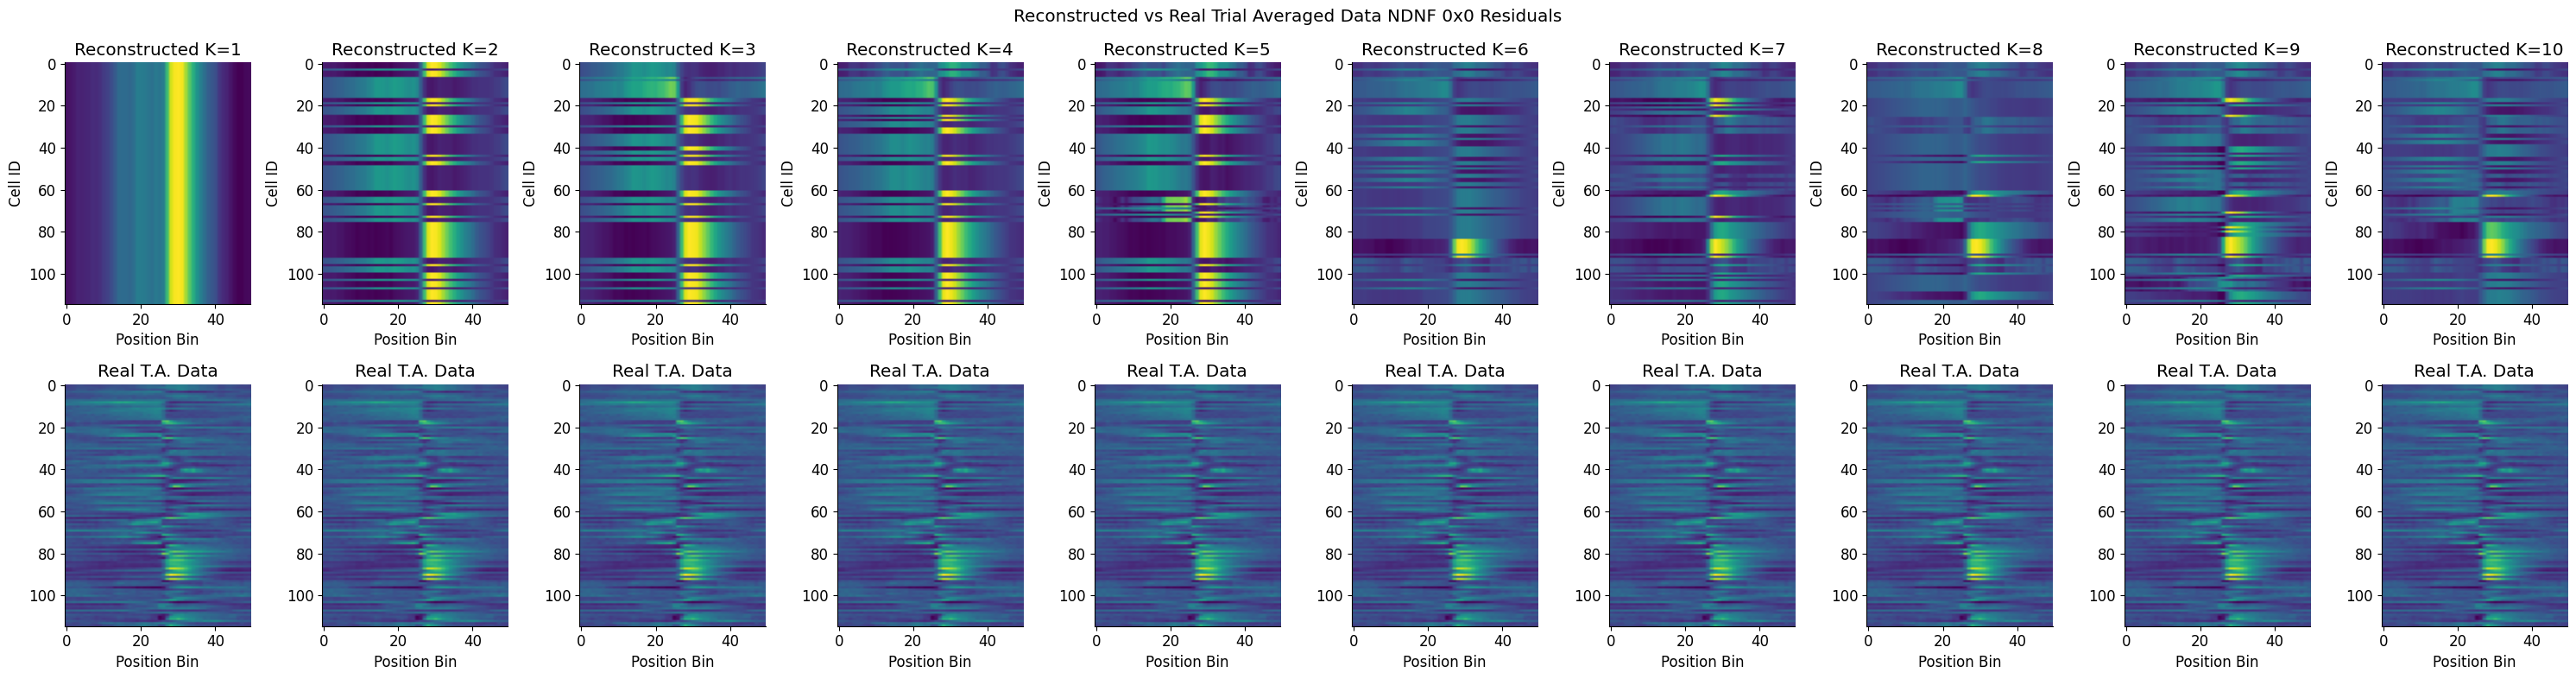

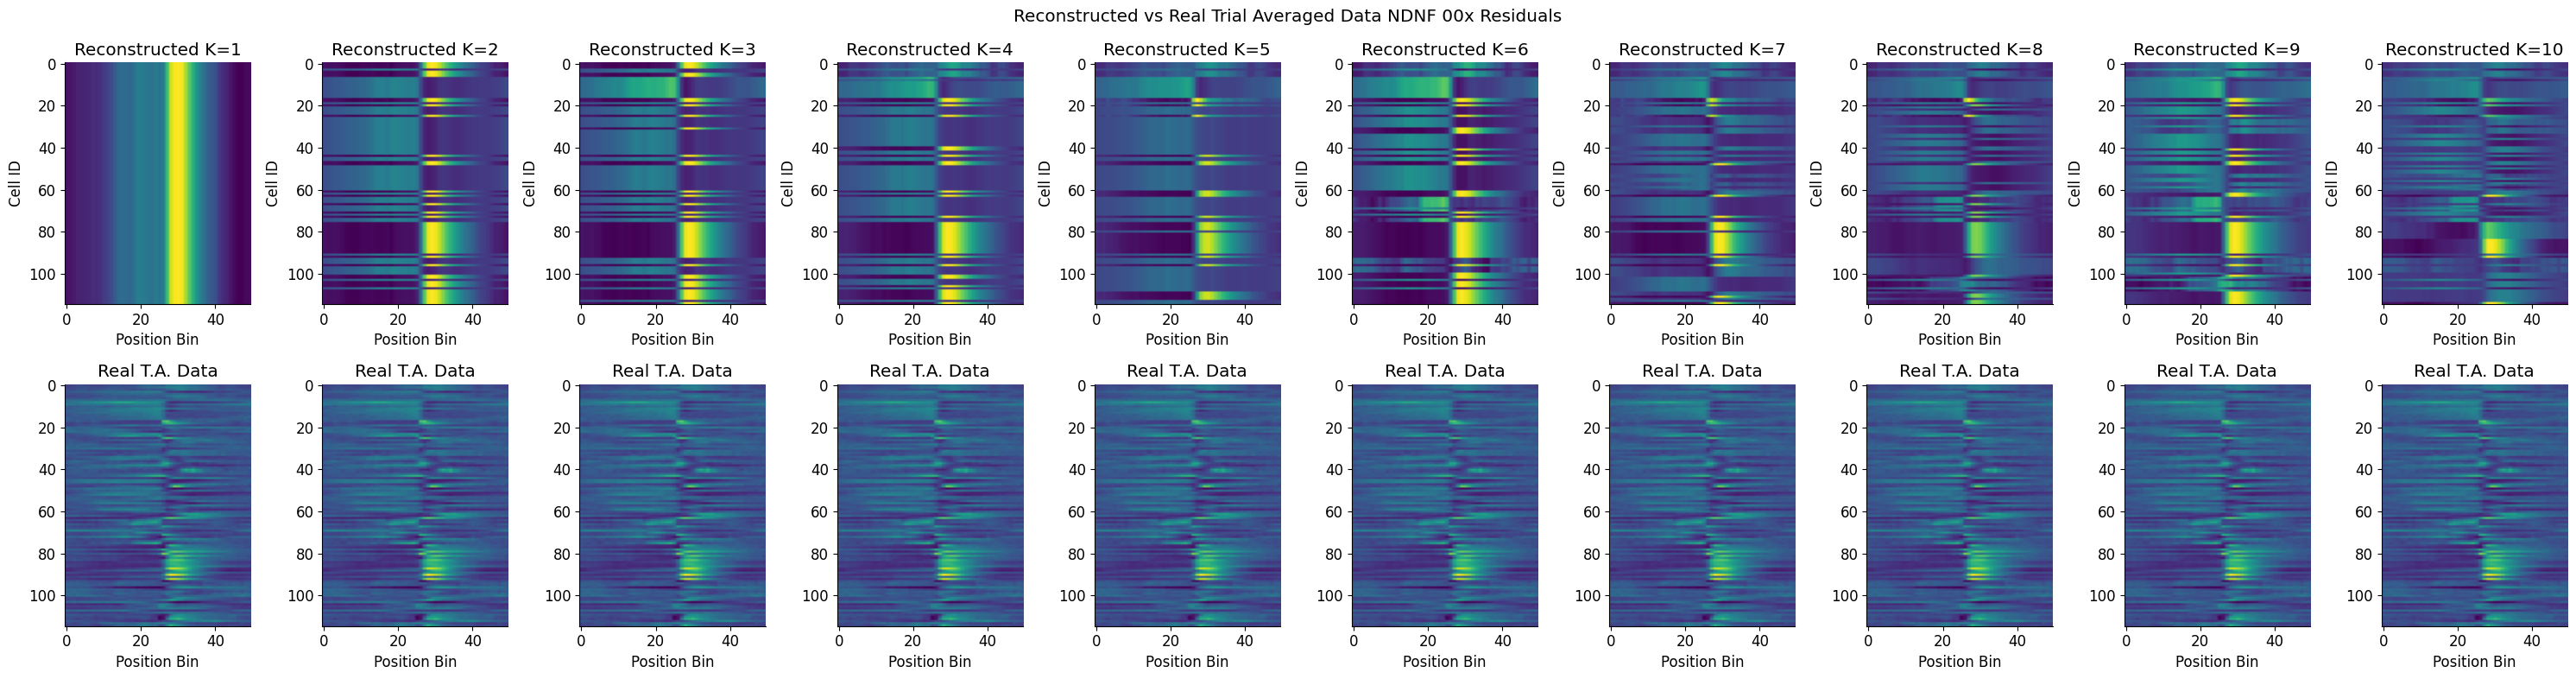

In [205]:
############ different r list? 

means_dict_cluster_x00_resid = plot_reconstructions(labels_cells_dict_all_K_NDNF_x00_resid, fixed_residual_activity_dict_NDNF_newest, r_dict_vel, r_dict_licks, prefix="NDNF x00 Residuals")
means_dict_cluster_0x0_resid = plot_reconstructions(labels_cells_dict_all_K_NDNF_0x0_resid, fixed_residual_activity_dict_NDNF_newest, r_dict_vel, r_dict_licks, prefix="NDNF 0x0 Residuals")
means_dict_cluster_00x_resid = plot_reconstructions(labels_cells_dict_all_K_NDNF_00x_resid, fixed_residual_activity_dict_NDNF_newest, r_dict_vel, r_dict_licks, prefix="NDNF 00x Residuals")


100.0


In [30]:
import numpy as np
from sklearn.preprocessing import StandardScaler, normalize

def get_cell_features(w1, f1, *,
                      feature_mode="x00", 
                      n_cells_expected=None,
                      n_latents_expected=None):
    """
      - "pos_profile":       (cells, pos) via weighted latent templates

    Notes:
      • If a chosen mode can’t be formed from the available axes, it raises a helpful error.
      • Pass n_cells_expected=115 (and n_latents_expected=20) to make detection strict.
    """
    # to numpy
    W = w1.detach().cpu().numpy()
    F = f1.detach().cpu().numpy()

    # small helpers
    def find_axis_by_size(shape, target):
        return shape.index(target) if (target in shape) else None

    def move_front(a, ax):
        return np.moveaxis(a, ax, 0)

    # Try to detect latents axis (often 20)
    Lw = find_axis_by_size(W.shape, n_latents_expected) if n_latents_expected else None
    Lf = find_axis_by_size(F.shape, n_latents_expected) if n_latents_expected else None
    # Detect cells axis (often 115)
    Cw = find_axis_by_size(W.shape, n_cells_expected) if n_cells_expected else None
    Cf = find_axis_by_size(F.shape, n_cells_expected) if n_cells_expected else None

    if feature_mode == "0x0":
        # Prefer W if it directly contains cells and latents
        if (Cw is not None) and (Lw is not None) and W.ndim >= 2:
            # bring cells first, latents second
            order = [Cw, Lw] + [ax for ax in range(W.ndim) if ax not in (Cw, Lw)]
            X = np.transpose(W, order)
            if X.ndim > 2:
                X = X.mean(axis=tuple(range(2, X.ndim)))  # collapse any extras
            # X is (cells, latents)
            return X

        # Else try F similarly
        if (Cf is not None) and (Lf is not None) and F.ndim >= 2:
            order = [Cf, Lf] + [ax for ax in range(F.ndim) if ax not in (Cf, Lf)]
            G = np.transpose(F, order)
            if G.ndim > 2:
                G = G.mean(axis=tuple(range(2, G.ndim)))
            return G  # (cells, latents)

        raise ValueError("Cannot form '0x0' (cells×latents): no cells+latents pairing found.")

    # ---- Option 2: latent × pos flattened (cells × (L*P)) ----
    if feature_mode == "x00":
        # We need a tensor that contains (latents, cells, pos) in some order
        # Check F first (most common)
        if Cf is not None and Lf is not None and 3 <= F.ndim <= 4:
            # find a pos-like axis: pick the remaining non-cells, non-latents axis
            rem = [ax for ax in range(F.ndim) if ax not in (Cf, Lf)]
            if not rem:
                raise ValueError("No pos axis found in F for latent_pos_flat.")
            pos_ax = rem[0]
            # reorder to (cells, latents, pos, [maybe ...])
            order = [Cf, Lf, pos_ax] + [ax for ax in rem[1:]]
            G = np.transpose(F, order)
            # if more dims exist, mean over them
            if G.ndim > 3:
                G = G.mean(axis=tuple(range(3, G.ndim)))
            C, L, P = G.shape
            X = G.reshape(C, L * P)
            return X
        # Else: if W has (latents, pos) and *no* cells, we can’t build per-cell features from W alone.
        raise ValueError("Cannot form 'latent_pos_flat' from current W/F: need latents+cells+pos together (usually in F).")

    # ---- Option 3: latent × trials flattened (cells × (L*T)) ----
    if feature_mode == "00x":
        # Need (latents, trials, cells) in some order
        if Cf is not None and Lf is not None and 3 <= F.ndim <= 4:
            rem = [ax for ax in range(F.ndim) if ax not in (Cf, Lf)]
            if not rem:
                raise ValueError("No trials axis found in F for latent_trials_flat.")
            tr_ax = rem[0]
            order = [Cf, Lf, tr_ax] + [ax for ax in rem[1:]]
            G = np.transpose(F, order)  # (cells, latents, trials, [maybe ...])
            if G.ndim > 3:
                G = G.mean(axis=tuple(range(3, G.ndim)))
            C, L, T = G.shape
            X = G.reshape(C, L * T)
            return X
        raise ValueError("Cannot form 'latent_trials_flat': need latents+cells+trials together (usually in F).")

    # ---- Option 4: pos_profile (cells × pos), via weighted templates if possible ----
    if feature_mode == "pos_profile":
        # If we have (latents,cells, pos) in F: average latents → (cells, pos)
        if Cf is not None and Lf is not None and 3 <= F.ndim:
            rem = [ax for ax in range(F.ndim) if ax not in (Cf, Lf)]
            pos_ax = rem[0] if rem else None
            if pos_ax is not None:
                order = [Cf, Lf, pos_ax] + [ax for ax in rem[1:]]
                G = np.transpose(F, order)  # (cells, latents, pos, ...)
                if G.ndim > 3:
                    G = G.mean(axis=tuple(range(3, G.ndim)))
                X = G.mean(axis=1)  # avg over latents -> (cells, pos)
                return X
        raise ValueError("Cannot form 'pos_profile' from current W/F.")

    raise ValueError(f"Unknown feature_mode: {feature_mode}")


In [242]:

def pca_cluster_viz(model_20_NDNF_raw_x00, which_vectors=0, feature_space="loadings", feature_mode=None, n_cells_expected=None, n_latents_expected=None, n_components=3, num_clusters=3, title_prefix="NDNF 3D PCA"):

    # put these at the top of the file once
    import numpy as np
    import matplotlib.pyplot as plt
    from sklearn.decomposition import PCA
    from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

    
    labels_cells_dict_all_K_NDNF = get_labels_all_different_Ks_single(model_20_NDNF_raw_x00, which_vectors=which_vectors)

    labels = np.asarray(labels_cells_dict_all_K_NDNF[num_clusters])

    # === features & PCA (reuse your helpers/steps) ===
    # X = get_cell_features(w1, f1, feature_space=feature_space)

    w1 = model_20_NDNF_raw_x00.vectors[which_vectors][0]
    f1 = model_20_NDNF_raw_x00.vectors[which_vectors][1]

    X = get_cell_features(w1, f1, feature_mode=feature_mode, 
                      n_cells_expected=n_cells_expected,
                      n_latents_expected=n_latents_expected)


    from sklearn.preprocessing import StandardScaler, normalize
    from sklearn.decomposition import PCA

    n_components = min(n_components, X.shape[1])
    if n_components < 3:
        raise ValueError(f"Need at least 3 PCs; got n_components={n_components}")
    pca = PCA(n_components=n_components, random_state=42)
    Z = pca.fit_transform(X)                   # (cells, n_components)
    evr = pca.explained_variance_ratio_         # len >= 3

    uniq = np.unique(labels)

    # === three subplots: (PC1,PC2), (PC2,PC3), (PC1,PC3) ===
    pairs = [(0,1), (1,2), (0,2)]
    fig, axs = plt.subplots(1, 3, figsize=(15, 4), sharex=False, sharey=False)

    handles = []
    for ax, (i, j) in zip(axs, pairs):
        for lab in uniq:
            m = labels == lab
            ax.scatter(Z[m, i], Z[m, j], s=28, alpha=0.9, label=f"C{lab} (n={m.sum()})")
        ax.set_xlabel(f"PC{i+1} ({evr[i]*100:.1f}%)", labelpad=8)   # <—
        ax.set_ylabel(f"PC{j+1} ({evr[j]*100:.1f}%)", labelpad=8)   # <—
        ax.set_title(f"PC{i+1} vs PC{j+1}", pad=12)                 # <—
        ax.axhline(0, lw=0.5, alpha=0.4)
        ax.axvline(0, lw=0.5, alpha=0.4)

    # single legend outside (avoid duplicates)
    # grab handles/labels from the last axis
    handles, labels_txt = axs[-1].get_legend_handles_labels()
    fig.legend(handles, labels_txt, loc="upper center", ncol=min(len(uniq), 6), frameon=False)
    # fig.suptitle(f"{title_prefix} PCA ({feature_space})", y=1.06, fontsize=12)

    fig.subplots_adjust(top=0.80)
    
    
    
    from mpl_toolkits.mplot3d import Axes3D  # noqa

    fig3d = plt.figure(figsize=(8, 6))  # a bit larger helps

    ax3d  = fig3d.add_subplot(111, projection='3d')

    # --- scatter ---
    for lab in uniq:
        m = labels == lab
        ax3d.scatter(Z[m,0], Z[m,1], Z[m,2], s=26, alpha=0.9, label=f"C{lab} (n={m.sum()})")

    # --- axis labels/title with extra padding ---
    ax3d.set_xlabel(f"PC1 ({evr[0]*100:.1f}%)", labelpad=18)
    ax3d.set_ylabel(f"PC2 ({evr[1]*100:.1f}%)", labelpad=18)
    ax3d.set_zlabel(f"PC3 ({evr[2]*100:.1f}%)", labelpad=18)
    ax3d.set_title(f"{title_prefix} 3D PCA", pad=18)

    # Give tick labels a little space from axes
    ax3d.tick_params(pad=6)  # space between ticks and tick labels

    # Put legend well outside so it never squeezes axes
    ax3d.legend(loc="center left", bbox_to_anchor=(1.28, 0.5), frameon=False, fontsize=9)

    # Reserve generous margins (no tight/constrained layout here)
    fig3d.subplots_adjust(left=0.08, right=0.72, bottom=0.10, top=0.88)

    # Optional: rotate view
    ax3d.view_init(elev=20, azim=35)

    plt.show()

    # from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

    # lda = LinearDiscriminantAnalysis(n_components=2)
    # X_lda = lda.fit_transform(X, labels)

    # uniq = np.unique(labels)

    # fig, ax = plt.subplots(figsize=(7.5, 5))  # a bit wider helps
    # for k in uniq:
    #     m = labels == k
    #     ax.scatter(X_lda[m, 0], X_lda[m, 1],
    #             s=40, alpha=0.6, label=f"C{k} (n={m.sum()})")

    # ax.set_xlabel("LDA Component 1")
    # ax.set_ylabel("LDA Component 2")
    # ax.set_title(f"LDA Projection {title_prefix}")

    # # Legend OUTSIDE on the right
    # leg = ax.legend(loc="center left", bbox_to_anchor=(1.02, 0.5),
    #                 frameon=False, ncol=1)

    # # Leave room on the right for the legend
    # fig.subplots_adjust(right=0.78)   # tweak to taste (smaller -> more space)

    # plt.show()


    def plot_lda_projection(X, labels, title_prefix="LDA Projection", cluster_subset=None):
        """
        If cluster_subset is given (e.g., (0,1)), restrict to those two classes.
        For 2 classes -> 1D LDA projection (strip+hist).
        For >=3 classes -> 2D LDA scatter (first two discriminants).
        """
        labels = np.asarray(labels)

        # Optional: restrict to chosen clusters (e.g., (0,1))
        if cluster_subset is not None:
            mask = np.isin(labels, cluster_subset)
            X = X[mask]
            labels = labels[mask]

        uniq = np.unique(labels)
        K = len(uniq)
        if K < 2:
            raise ValueError("Need at least 2 classes for LDA.")

        # LDA components: at most min(2, K-1, X.shape[1])
        nlda = min(2, K-1, X.shape[1])
        lda = LinearDiscriminantAnalysis(n_components=nlda)
        X_lda = lda.fit_transform(X, labels)

        if nlda == 1:
            # --- 1D visualization for two classes ---
            fig, ax = plt.subplots(figsize=(8, 3.8))
            # small vertical jitter for visibility
            y_jitter = 0.08

            # plot class-wise strips + overlaid histograms
            for i, k in enumerate(uniq):
                m = (labels == k)
                xk = X_lda[m, 0]

                # strip
                ax.scatter(xk, np.full_like(xk, i) + (np.random.rand(xk.size)-0.5)*y_jitter,
                        s=14, alpha=0.7, label=f"C{k} (n={m.sum()})")

                # class histogram along x (transparent)
                hist_y, bin_edges = np.histogram(xk, bins=30)
                hist_y = hist_y.astype(float) / hist_y.max() if hist_y.max() else hist_y
                centers = 0.5*(bin_edges[:-1] + bin_edges[1:])
                ax.plot(centers, i + 0.35*hist_y, lw=1.2, alpha=0.8)

                # class median
                ax.axvline(np.median(xk), ymin=(i/ (K)), ymax=((i+1)/K), ls='--', lw=1, alpha=0.6)

            ax.set_yticks(range(K))
            ax.set_yticklabels([f"C{k}" for k in uniq])
            ax.set_xlabel("LDA component 1")
            ax.set_title(f"{title_prefix} (2 classes → 1D)")
            ax.legend(loc="upper right", frameon=False)
            ax.grid(axis='x', alpha=0.2)
            plt.tight_layout()
            plt.show()

        else:
            # --- 2D visualization for K >= 3 ---
            fig, ax = plt.subplots(figsize=(7.5, 5))
            for k in uniq:
                m = (labels == k)
                ax.scatter(X_lda[m, 0], X_lda[m, 1], s=40, alpha=0.6, label=f"C{k} (n={m.sum()})")
            ax.set_xlabel("LDA component 1")
            ax.set_ylabel("LDA component 2")
            ax.set_title(title_prefix)
            ax.legend(loc="center left", bbox_to_anchor=(1.02, 0.5), frameon=False)
            fig.subplots_adjust(right=0.78)
            plt.show()

    plot_lda_projection(X, labels, title_prefix=f"LDA {title_prefix}")


   



# pca_cluster_viz_triptych(model_20_NDNF_raw_x00, which_vectors=0, feature_space="loadings", feature_mode="x00", n_cells_expected=115, n_latents_expected=20, num_clusters=3, title_prefix="NDNF x00 Raw")



F.shape (20, 115, 50)  W.shape (20, 100)
X shape (latent×pos flat): (115, 1000)


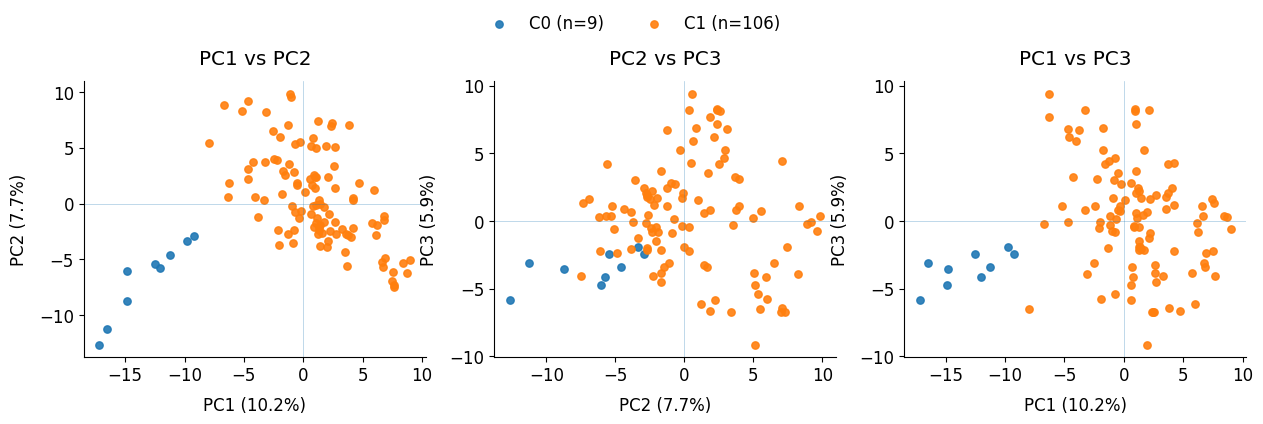

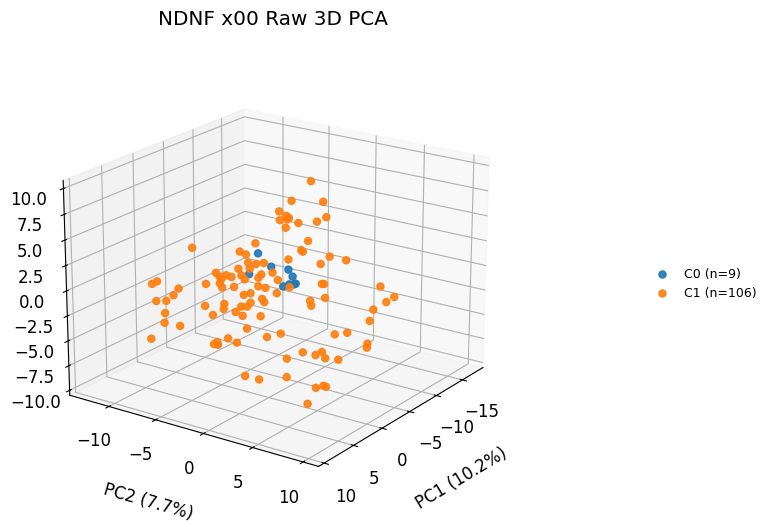

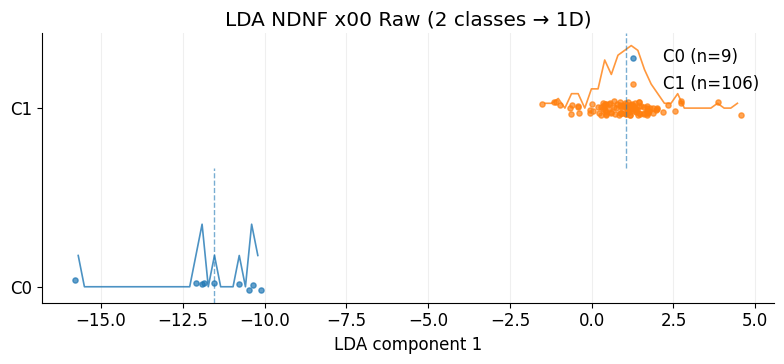

In [243]:
pca_cluster_viz(model_20_NDNF_raw_x00, which_vectors=0, feature_space="loadings", feature_mode="x00", n_cells_expected=115, n_latents_expected=20, num_clusters=2, title_prefix="NDNF x00 Raw")

# pca_cluster_viz(model_20_NDNF_raw_0x0, which_vectors=1, feature_space="loadings", feature_mode="0x0", n_cells_expected=115, n_latents_expected=20, num_clusters=4, title_prefix="NDNF 0x0 Raw")

# pca_cluster_viz(model_20_NDNF_raw_00x, which_vectors=2, feature_space="loadings", feature_mode="00x", n_cells_expected=115, n_latents_expected=20, num_clusters=4, title_prefix="NDNF 00x Raw")



# pca_cluster_viz(model_20_NDNF_resid_x00, which_vectors=0, feature_space="loadings", feature_mode="x00", n_cells_expected=115, n_latents_expected=20, num_clusters=3, title_prefix="NDNF x00 Residuals")

# pca_cluster_viz(model_20_NDNF_resid_0x0, which_vectors=1, feature_space="loadings", feature_mode="0x0", n_cells_expected=115, n_latents_expected=20, num_clusters=3, title_prefix="NDNF 0x0 Residuals")

# pca_cluster_viz(model_20_NDNF_resid_00x, which_vectors=2, feature_space="loadings", feature_mode="00x", n_cells_expected=115, n_latents_expected=20, num_clusters=3, title_prefix="NDNF 00x Residuals")





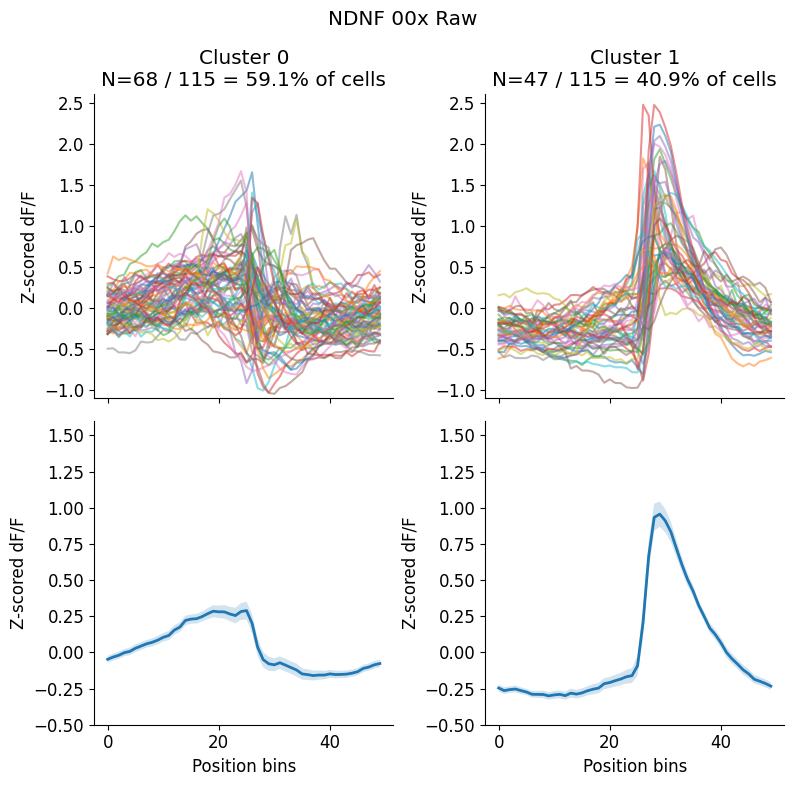

In [232]:

def plot_per_cell_clustering(labels_cells_dict_all_K_NDNF, fixed_activity_dict_NDNF_newest, num_clusters: int, prefix:str):
    labels_4_clust = np.asarray(labels_cells_dict_all_K_NDNF[num_clusters])
    uniq = np.unique(labels_4_clust)

    # data: expect (cells, pos, trials); move/choose axis if needed
    data = get_truncated_to_min_data_array(fixed_activity_dict_NDNF_newest)
  
    n_cells, n_pos, n_trials = data.shape

    separated_data_dict = {}
    separated_data_dict_ta = {}
    count_dict = {}
    total_count = 0

    label_to_col = {lab: j for j, lab in enumerate(uniq)}

    for lab in uniq:
        labels_loc = np.where(labels_4_clust == lab)[0]
        data_trunc = data[labels_loc, :, :]                 # (n_k, n_pos, n_trials)
        separated_data_dict[lab] = data_trunc
        separated_data_dict_ta[lab] = np.mean(data_trunc, axis=2)  # (n_k, n_pos)
        count_dict[lab] = len(labels_loc)
        total_count += len(labels_loc)

    # Sanity check: did we keep all cells?
    if total_count != n_cells:
        missing = n_cells - total_count
        print(f"[warn] {missing} cells not assigned across clusters (total {total_count}/{n_cells}={(total_count/n_cells)*100}%).")

    # Plot
    C = len(separated_data_dict_ta)
    fig, axs = plt.subplots(2, C, figsize=(4*C, 8), sharex=True)
    plt.suptitle(prefix)
    if C == 1:  # keep indexing consistent
        axs = np.array(axs).reshape(2, 1)

    for lab, clust_data in separated_data_dict_ta.items():
        col = label_to_col[lab]
        mean_clust = clust_data.mean(axis=0)           
        sem_clust  = sem(clust_data, axis=0)          

        for i in range(clust_data.shape[0]):
            axs[0, col].plot(clust_data[i, :], alpha=0.5)

        axs[1, col].plot(mean_clust, lw=2)
        axs[1, col].fill_between(np.arange(n_pos), mean_clust - sem_clust, mean_clust + sem_clust, alpha=0.2)

        axs[0, col].set_title(f"Cluster {lab}\nN={count_dict[lab]} / {total_count} = {(count_dict[lab]/total_count)*100:.1f}% of cells")
        axs[0, col].set_ylabel("Z-scored dF/F")
        axs[1, col].set_ylabel("Z-scored dF/F")
        axs[1, col].set_xlabel("Position bins")

        axs[0, col].set_ylim(-1.1, 2.6)
        axs[1, col].set_ylim(-0.5, 1.6)

    plt.tight_layout()
    plt.show()

# plot_per_cell_clustering(labels_cells_dict_all_K_NDNF, num_clusters=6)
plot_per_cell_clustering(labels_cells_dict_all_K_NDNF_00x_raw, fixed_activity_dict_NDNF_newest, num_clusters=2, prefix="NDNF 00x Raw")

#labels_cells_dict_all_K_NDNF_00x_raw

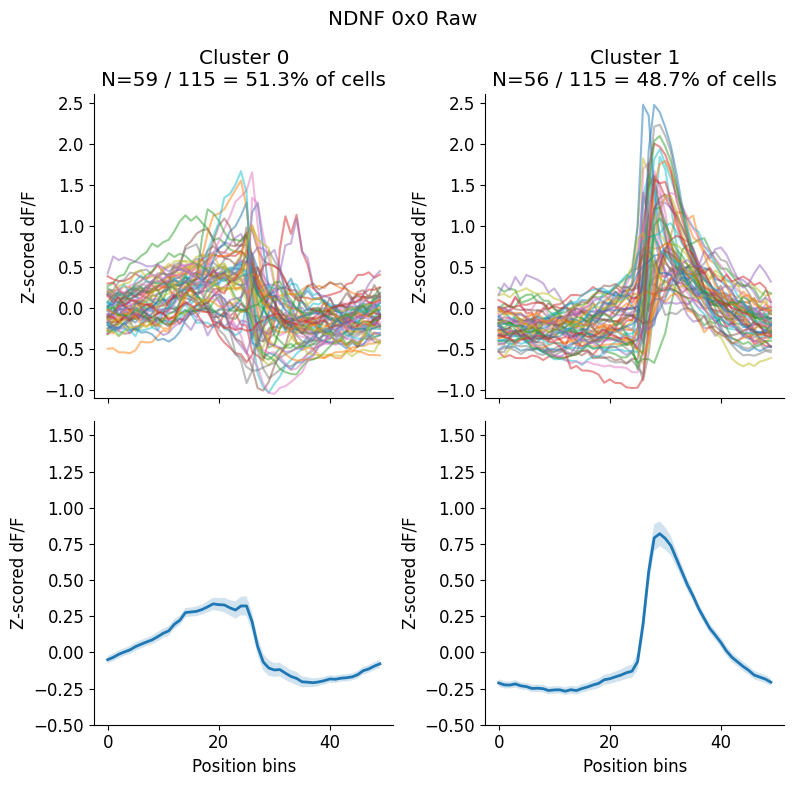

In [44]:
plot_per_cell_clustering(labels_cells_dict_all_K_NDNF_0x0_raw, fixed_activity_dict_NDNF_newest, num_clusters=2, prefix="NDNF 0x0 Raw")


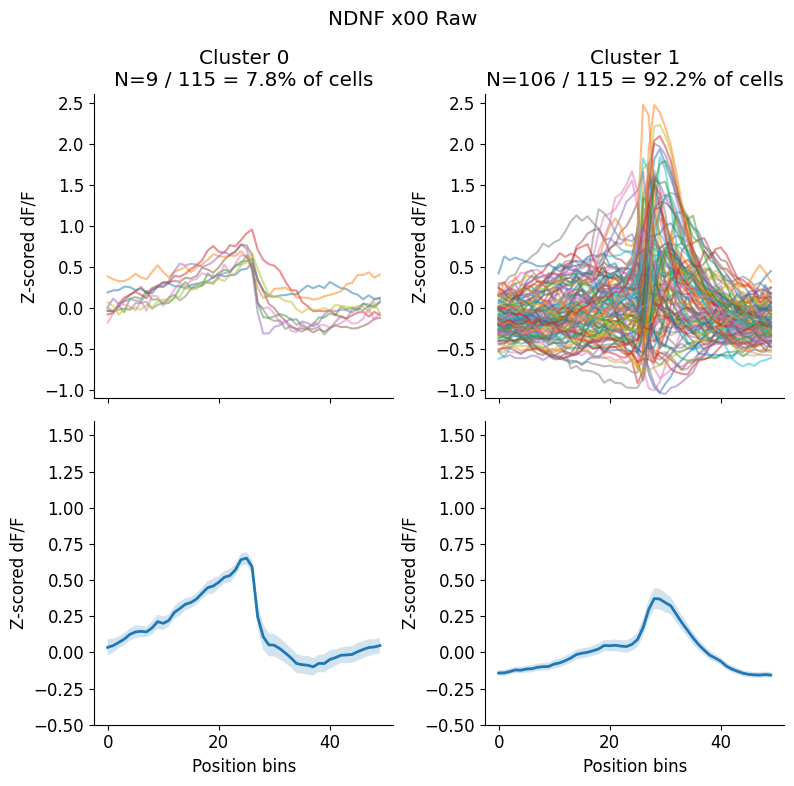

In [45]:
plot_per_cell_clustering(labels_cells_dict_all_K_NDNF_x00_raw, fixed_activity_dict_NDNF_newest, num_clusters=2, prefix="NDNF x00 Raw")


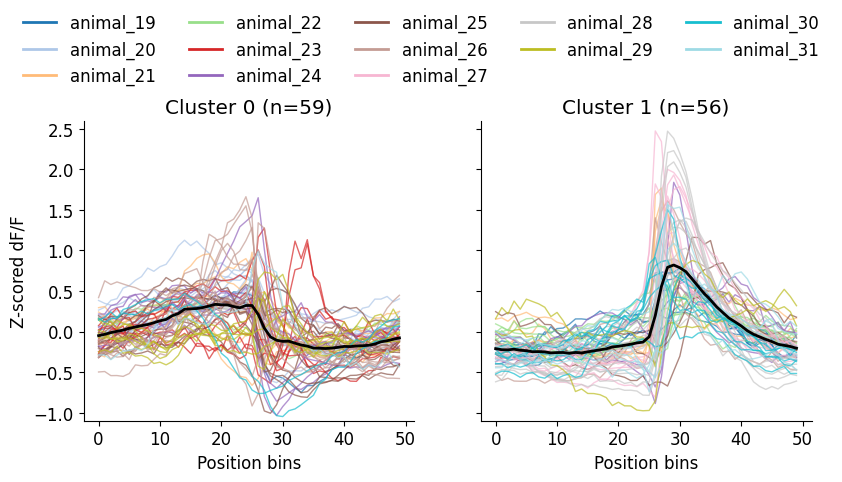

In [256]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import sem

def plot_cluster_traces_by_animal(
    means_dict_cluster,                 # output from plot_reconstructions (has cell_ids_per_cluster_dict)
    fixed_activity_dict_NDNF_newest,    # to recompute TA traces
    cells_per_animal_dict,              # {animal: [global_cell_ids...]}
    K,                                  # which K to plot
    ylim=(-1.1, 2.6), ncol=None,
    title_prefix=""
):
    # --- build cell_id -> animal map ---
    cell_to_animal = {}
    for animal, cell_ids in cells_per_animal_dict.items():
        for cid in cell_ids:
            cell_to_animal[cid] = animal

    # --- get TA data (cells × pos) ---
    data = get_truncated_to_min_data_array(fixed_activity_dict_NDNF_newest)  # (cells, pos, trials)
    ta = data.mean(axis=2)                                                   # (cells, pos)
    n_cells, n_pos = ta.shape

    # --- clusters & subplot layout ---
    clust_idx_dict = means_dict_cluster[K]["cell_ids_per_cluster_dict"]      # {cluster_label: array(cell_ids)}
    uniq = sorted(clust_idx_dict.keys())
    label_to_col = {lab: j for j, lab in enumerate(uniq)}

    # --- color map per animal ---
    animals = sorted(set(cell_to_animal.values()))
    cmap = plt.get_cmap("tab20", len(animals))
    animal_to_color = {a: cmap(i) for i, a in enumerate(animals)}

    fig, axs = plt.subplots(1, len(uniq), figsize=(4*len(uniq), 6), sharey=True)
    if len(uniq) == 1:
        axs = np.array([axs])

    for lab in uniq:
        ax = axs[label_to_col[lab]]
        idx = np.asarray(clust_idx_dict[lab])
        traces = ta[idx]                                   # (n_k, n_pos)

        # plot each cell trace colored by its animal
        for cid in idx:
            a = cell_to_animal.get(int(cid), "unknown")
            color = animal_to_color.get(a, (0.5,0.5,0.5,0.6))
            ax.plot(traces[np.where(idx==cid)[0][0], :], lw=1.0, alpha=0.7, color=color)

        # overlay mean ± SEM (neutral color)
        m = traces.mean(axis=0)
        s = sem(traces, axis=0) if traces.shape[0] > 1 else np.zeros_like(m)
        ax.plot(m, lw=2.0, color="k")
        ax.fill_between(np.arange(n_pos), m - s, m + s, alpha=0.15, color="k")

        ax.set_title(f"Cluster {lab} (n={len(idx)})")
        ax.set_xlabel("Position bins")
        ax.set_ylim(*ylim)
    axs[0].set_ylabel("Z-scored dF/F")
    # fig.suptitle(f"{title_prefix} Traces colored by animal — K={K}", y=1.02, fontsize=12)

    # legend outside: one entry per animal
    handles = [plt.Line2D([0],[0], color=animal_to_color[a], lw=2) for a in animals]
    labels = [f"{a}" for a in animals]
    fig.legend(handles, labels, loc="upper center", ncol=ncol, frameon=False)
    fig.subplots_adjust(top=0.8, right=0.98, left=0.07, bottom=0.3)
    plt.show()


plot_cluster_traces_by_animal(means_dict_cluster_0x0_raw,
                              fixed_activity_dict_NDNF_newest,
                              cells_per_animal_dict,
                              K=2,ncol=5,
                              title_prefix="NDNF 0x0 Raw")

# plot_cluster_traces_by_animal(means_dict_cluster_0x0_resid,
#                               fixed_residual_activity_dict_NDNF_newest,
#                               cells_per_animal_dict,
#                               K=2,
#                               ncol=5,
#                               title_prefix="NDNF")





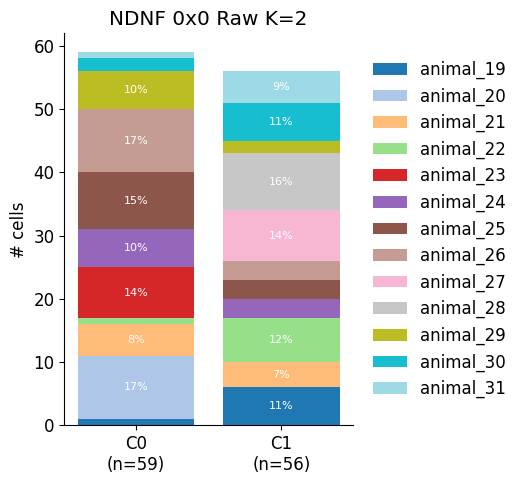

In [267]:
import numpy as np
import matplotlib.pyplot as plt

def plot_cluster_animal_composition_stacked(means_dict_cluster, cells_per_animal_dict, K,
                                            title_prefix="", show_percent_labels=False):
    # --- build cell_id -> animal map ---
    cell_to_animal = {}
    for animal, cell_ids in cells_per_animal_dict.items():
        for cid in cell_ids:
            cell_to_animal[int(cid)] = animal

    # --- cluster membership dict for this K ---
    clust_idx_dict = means_dict_cluster[K]["cell_ids_per_cluster_dict"]  # {cluster_label: array(cell_ids)}
    clusters = sorted(clust_idx_dict.keys())  # keep order stable

    # --- all animals & consistent colors ---
    animals = sorted(set(cell_to_animal.values()))
    cmap = plt.get_cmap("tab20", len(animals))
    animal_to_color = {a: cmap(i) for i, a in enumerate(animals)}

    # --- counts matrix: rows=clusters, cols=animals ---
    counts = np.zeros((len(clusters), len(animals)), dtype=int)
    for r, clab in enumerate(clusters):
        for cid in clust_idx_dict[clab]:
            a = cell_to_animal.get(int(cid), None)
            if a is not None:
                c = animals.index(a)
                counts[r, c] += 1

    totals = counts.sum(axis=1)  # cells per cluster

    # --- plot stacked bars (height = counts, stacked by animal) ---
    x = np.arange(len(clusters))
    fig, ax = plt.subplots(figsize=(1.2*len(clusters)+3, 5))
    bottom = np.zeros_like(totals, dtype=float)

    bars = []
    for j, a in enumerate(animals):
        b = ax.bar(x, counts[:, j], bottom=bottom, width=0.8,
                   color=animal_to_color[a], label=f"{a}")
        bars.append(b)
        bottom += counts[:, j]

    # x-ticks as cluster labels with n
    ax.set_xticks(x, [f"C{clab}\n(n={totals[i]})" for i, clab in enumerate(clusters)])
    ax.set_ylabel("# cells")
    ax.set_title(f"{title_prefix} K={K}")

    # optional % labels inside segments
    if show_percent_labels:
        with np.errstate(divide='ignore', invalid='ignore'):
            props = counts / totals[:, None]
            props[np.isnan(props)] = 0.0
        for i in range(len(clusters)):
            cum = 0.0
            for j in range(len(animals)):
                h = counts[i, j]
                if h > 0 and props[i, j] >= 0.07:  # only label if ≥7% to avoid clutter
                    ax.text(x[i], cum + h/2.0, f"{props[i, j]*100:.0f}%",
                            ha="center", va="center", fontsize=8, color="white")
                cum += h

    # legend outside
    ax.legend(loc="center left", bbox_to_anchor=(1.02, 0.5), frameon=False)
    fig.subplots_adjust(right=0.78)
    plt.tight_layout()
    plt.show()

# Example call:
plot_cluster_animal_composition_stacked(means_dict_cluster_0x0_raw, cells_per_animal_dict, K=2,
                                        title_prefix="NDNF 0x0 Raw", show_percent_labels=True)


In [48]:
model_20_NDNF_raw_x00_reconstruction = model_20_NDNF_raw_x00.construct().numpy(force=True)

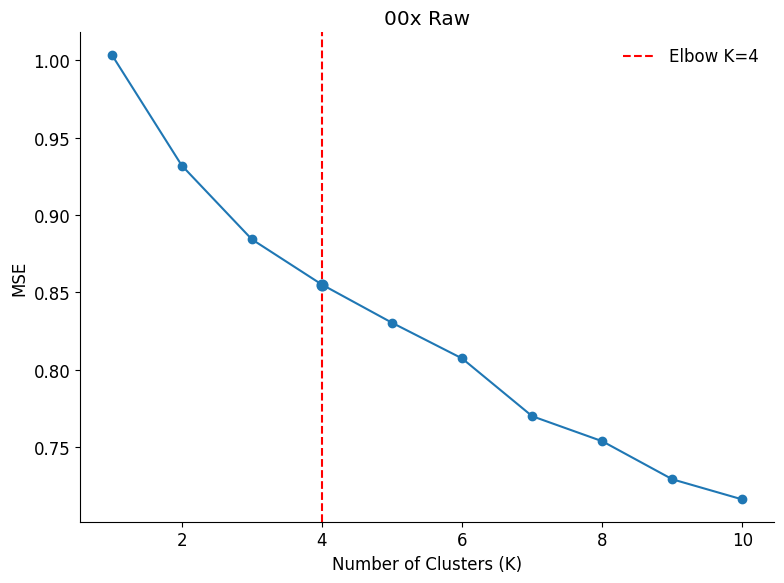

Elbow K: 4


In [ ]:
### get elbow working

import numpy as np
import matplotlib.pyplot as plt
from kneed import KneeLocator

def plot_elbow(means_dict_cluster, title:str):
    # Build x=K (sorted) and y=MSE arrays
    Ks, MSEs = zip(*sorted(((int(K), means_dict_cluster[K]["MSE_reco_vs_real"]) for K in means_dict_cluster),key=lambda kv: kv[0]))
    Ks   = np.array(Ks)
    MSEs = np.array(MSEs, dtype=float)

    if MSEs.size >= 3:
        pad = np.r_[MSEs[0], MSEs, MSEs[-1]]
        MSEs_smooth = np.convolve(pad, np.ones(3)/3, mode='valid')
    else:
        MSEs_smooth = MSEs

    kneedle = KneeLocator(Ks, MSEs_smooth,curve="convex", direction="decreasing", S=1.0)

    elbow_K = kneedle.knee  

    plt.figure(figsize=(8,6))
    plt.plot(Ks, MSEs, marker="o")
    if elbow_K is not None:
        plt.axvline(elbow_K, linestyle="--", label=f"Elbow K={elbow_K}", color='r')
        # Mark the point closest to elbow_K
        elbow_idx = int(np.argmin(np.abs(Ks - elbow_K)))
        plt.scatter([Ks[elbow_idx]], [MSEs[elbow_idx]], s=60, zorder=3)
    else:
        # Fallback: choose K at max drop in MSE (first difference)
        if len(Ks) > 1:
            diffs = np.diff(MSEs)
            elbow_idx = int(np.argmin(diffs)) + 1  # +1 → right side of steepest drop
            elbow_K = Ks[elbow_idx]
            plt.axvline(elbow_K, linestyle="--", label=f"Fallback K={elbow_K}")

    plt.xlabel("Number of Clusters (K)")
    plt.ylabel("MSE")
    plt.title(title)
    plt.legend(frameon=False)
    plt.tight_layout()
    plt.show()

    print("Elbow K:", elbow_K)

plot_elbow(means_dict_cluster_00x_raw, title="NDNF 00x Raw")

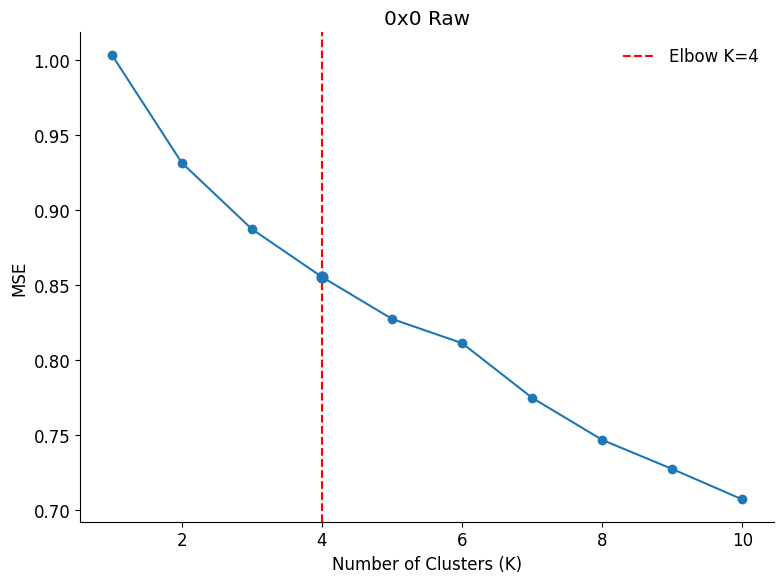

Elbow K: 4


In [ ]:

plot_elbow(means_dict_cluster_0x0_raw, title="NDNF 0x0 Raw")

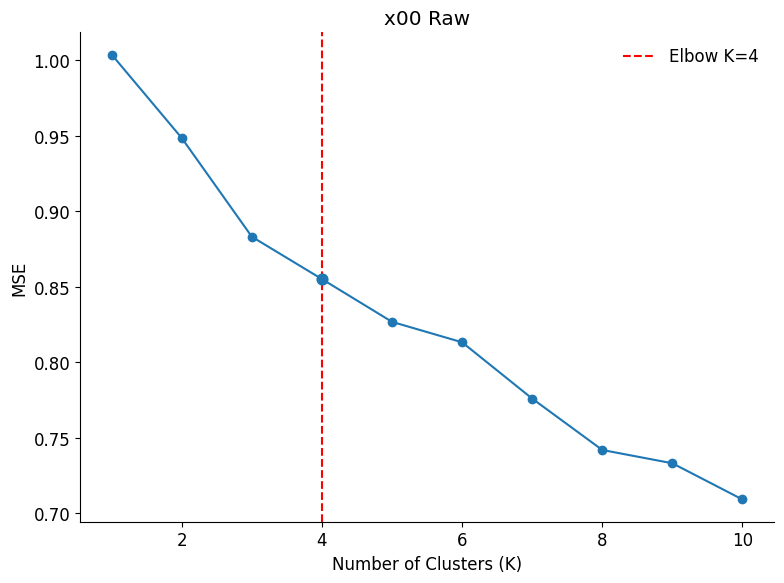

Elbow K: 4


In [ ]:

plot_elbow(means_dict_cluster_x00_raw, title="NDNF x00 Raw")

In [74]:
means_dict_cluster_00x_raw[3].keys()

dict_keys(['mean_data_list', 'fraction_cells', 'MSE_reco_vs_real', 'r_vel_dict_per_clust', 'r_lick_dict_per_clust'])

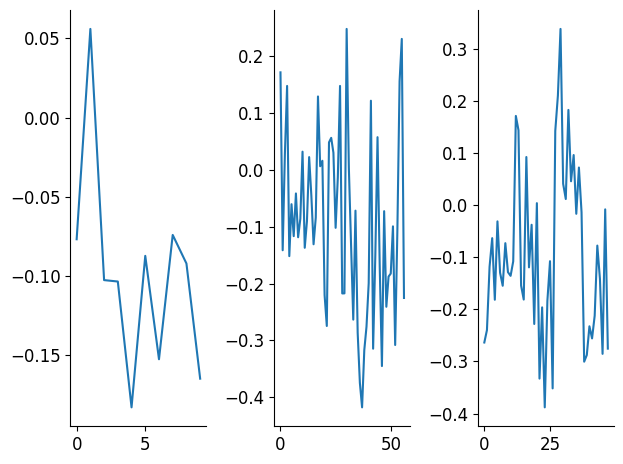

In [71]:

r_vel_per_clust_dict = means_dict_cluster_00x_raw[3]["r_vel_dict_per_clust"]

fig, axs = plt.subplots(1,len(r_vel_per_clust_dict))
for idx, clust in enumerate(r_vel_per_clust_dict):
    axs[clust].plot(r_vel_per_clust_dict[clust])

plt.tight_layout()
plt.show()




In [81]:

def plot_histogram_velocity_correlations(means_dict_cluster_00x_raw, num_clusters=3, correlate_vel=True, title=""):

    if correlate_vel:
        r_vel_per_clust_dict = means_dict_cluster_00x_raw[num_clusters]["r_vel_dict_per_clust"]
    else:
        r_vel_per_clust_dict = means_dict_cluster_00x_raw[num_clusters]["r_lick_dict_per_clust"]


    r_dict = r_vel_per_clust_dict  # {cluster_id: 1D array/list of r's}
    clusters = sorted(r_dict.keys())

    # 1) Choose common bins for r in [-1, 1]
    bins = np.linspace(-1, 1, 21)         # 20 bins
    centers = 0.5 * (bins[:-1] + bins[1:])
    widths  = np.diff(bins)

    # 2) Histogram counts per cluster (no normalization)
    counts = []
    ns = []
    for k in clusters:
        r = np.asarray(r_dict[k], dtype=float)
        r = r[np.isfinite(r)]
        ns.append(r.size)
        h, _ = np.histogram(r, bins=bins)
        counts.append(h)
    counts = np.asarray(counts)            # shape (C, B)

    # 3) Total count per bin (what the bar height should be)
    totals = counts.sum(axis=0)            # shape (B,)

    # 4) Plot stacked bars: heights are raw counts; colors show composition
    fig, ax = plt.subplots(figsize=(9, 4.8))
    bottom = np.zeros_like(totals, dtype=float)

    for i, k in enumerate(clusters):
        ax.bar(
            centers, counts[i], width=widths, bottom=bottom, align='center',
            label=f"C{k} (n={ns[i]})", alpha=0.9, linewidth=0
        )
        bottom += counts[i]

    # (Optional) draw a thin outline at the top of each bar to emphasize total height
    ax.bar(centers, totals, width=widths, align='center',fill=False, edgecolor='k', linewidth=0.8)

    if correlate_vel:
        ax.set_xlabel("r Activity vs Velocity")
    else:
        ax.set_xlabel("r Activity vs Licks")
    ax.set_ylabel("Count of cells")
    if correlate_vel:
        ax.set_title(f"{title} Velocity Correlation")
    else:
        ax.set_title(f"{title} Lick Correlation")

    ax.set_xlim(bins[0], bins[-1])

    # Legend outside
    ax.legend(loc="center left", bbox_to_anchor=(1.02, 0.5), frameon=False)
    fig.subplots_adjust(right=0.78)
    plt.tight_layout()
    plt.show()


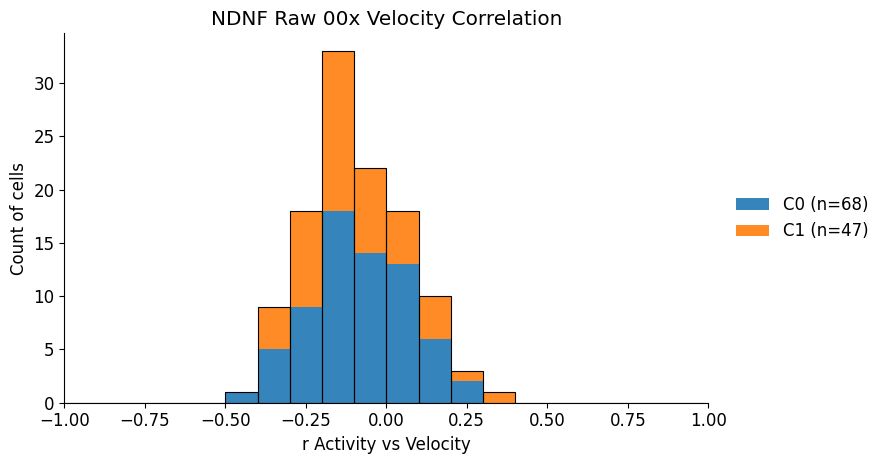

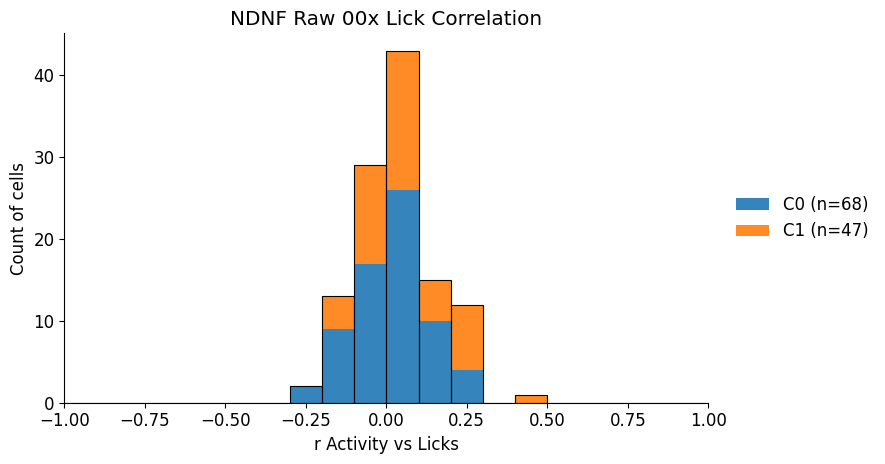

In [86]:
K=2

plot_histogram_velocity_correlations(means_dict_cluster_00x_raw, num_clusters=K, correlate_vel=True, title="NDNF Raw 00x")
plot_histogram_velocity_correlations(means_dict_cluster_00x_raw, num_clusters=K, correlate_vel=False, title="NDNF Raw 00x")

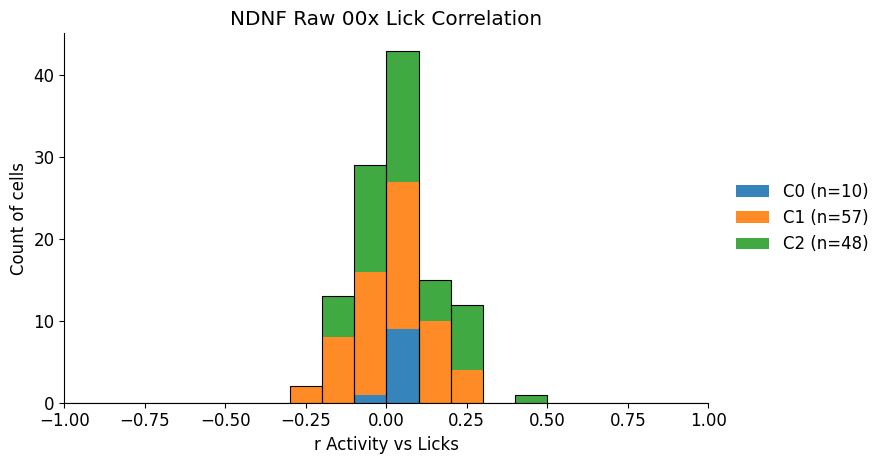

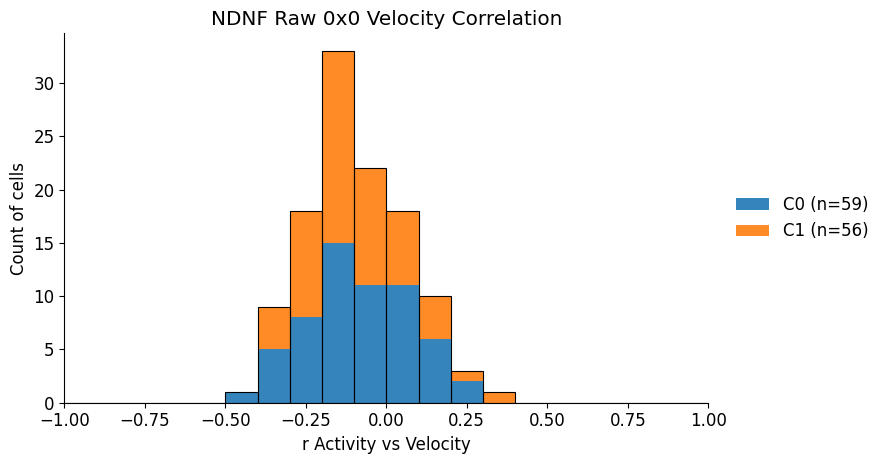

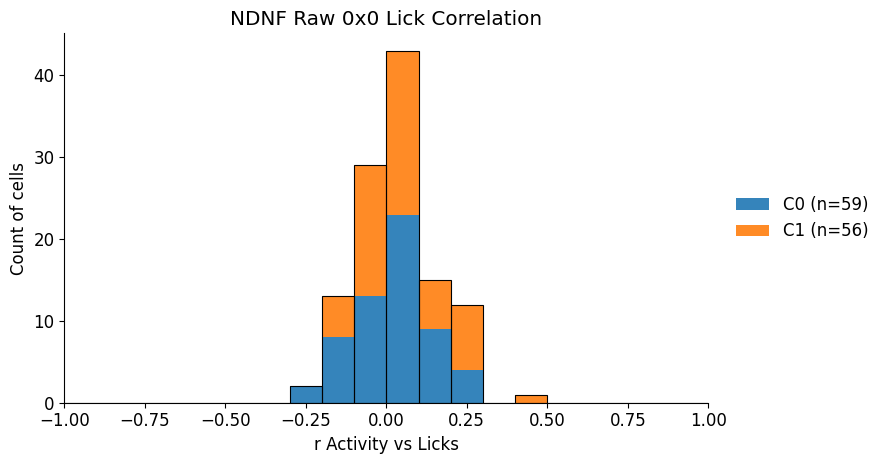

In [87]:
K=2

plot_histogram_velocity_correlations(means_dict_cluster_0x0_raw, num_clusters=K, correlate_vel=True, title="NDNF Raw 0x0")
plot_histogram_velocity_correlations(means_dict_cluster_0x0_raw, num_clusters=K, correlate_vel=False, title="NDNF Raw 0x0")

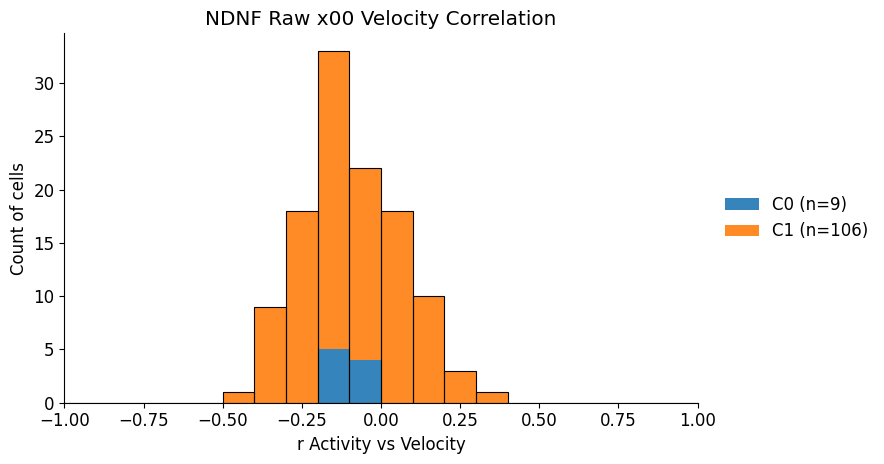

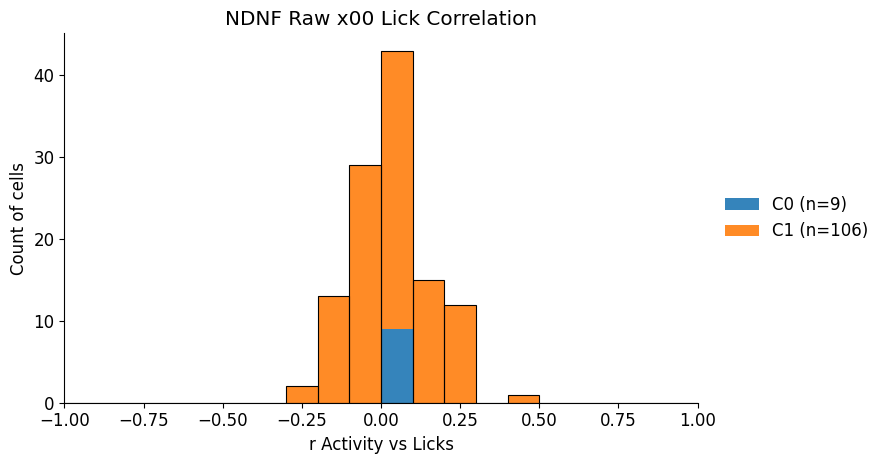

In [88]:
K=2

plot_histogram_velocity_correlations(means_dict_cluster_x00_raw, num_clusters=K, correlate_vel=True, title="NDNF Raw x00")
plot_histogram_velocity_correlations(means_dict_cluster_x00_raw, num_clusters=K, correlate_vel=False, title="NDNF Raw x00")

In [228]:
import numpy as np
import matplotlib.pyplot as plt

def plot_violin_correlations_side_by_side(means_dict_cluster_00x_raw, num_clusters=3, title=""):
    """
    Makes two side-by-side violin plots of per-cell correlation coefficients (r)
    for Velocity and Lick regressors, split by cluster.

    Expects:
      means_dict_cluster_00x_raw[num_clusters]["r_vel_dict_per_clust"] -> {cluster_id: iterable of r}
      means_dict_cluster_00x_raw[num_clusters]["r_lick_dict_per_clust"] -> {cluster_id: iterable of r}
    """
    d = means_dict_cluster_00x_raw[num_clusters]
    r_vel = d["r_vel_dict_per_clust"]
    r_lick = d["r_lick_dict_per_clust"]

    clusters = sorted(set(r_vel.keys()) | set(r_lick.keys()))
    # gather clean arrays per cluster
    vel_data = []
    lick_data = []
    labels = []
    for k in clusters:
        v = np.asarray(r_vel.get(k, []), dtype=float)
        l = np.asarray(r_lick.get(k, []), dtype=float)
        v = v[np.isfinite(v)]
        l = l[np.isfinite(l)]
        vel_data.append(v)
        lick_data.append(l)
        labels.append(f"C{k}\n n={len(l)}")

    # figure & axes
    fig, axes = plt.subplots(1, 2, figsize=(12, 4.6), sharey=True)
    ax_v, ax_l = axes

    # helper for one panel
    def _one_violin(ax, data, panel_title):
        parts = ax.violinplot(
            data,
            showmeans=False,
            showmedians=False,
            showextrema=False
        )
        # style the violins
        for pc in parts['bodies']:
            pc.set_alpha(0.7)
            pc.set_edgecolor('black')
            pc.set_linewidth(0.6)

        # add median & IQR markers per group
        positions = np.arange(1, len(data) + 1)
        medians = [np.median(a) if len(a) else np.nan for a in data]
        q1 = [np.percentile(a, 25) if len(a) else np.nan for a in data]
        q3 = [np.percentile(a, 75) if len(a) else np.nan for a in data]

        # IQR bars
        for x, lo, hi in zip(positions, q1, q3):
            if np.isfinite(lo) and np.isfinite(hi):
                ax.plot([x, x], [lo, hi], lw=3, solid_capstyle='round', alpha=0.9)

        # median points
        ax.scatter(positions, medians, s=18, zorder=3)

        ax.set_xticks(positions)
        ax.set_xticklabels(labels)
        ax.set_xlim(0.5, len(data) + 0.5)
        ax.set_title(panel_title)
        ax.grid(axis='y', alpha=0.2)

    _one_violin(ax_v, vel_data, f"{title} Velocity correlation (r)")
    _one_violin(ax_l, lick_data, f"{title} Lick correlation (r)")

    # shared y label and consistent limits
    all_vals = np.concatenate([np.concatenate([a for a in vel_data if len(a)]),
                               np.concatenate([a for a in lick_data if len(a)])]) if any(len(a) for a in vel_data+lick_data) else np.array([0.0])
    ylo = min(-1.0, np.nanmin(all_vals) if all_vals.size else -1.0)
    yhi = max(1.0, np.nanmax(all_vals) if all_vals.size else 1.0)
    for ax in axes:
        ax.set_ylim(ylo, yhi)
        ax.set_ylabel("Correlation coefficient r")

    fig.suptitle(f"{title} Correlations by Cluster", y=1.02, fontsize=12)
    fig.tight_layout()
    plt.show()


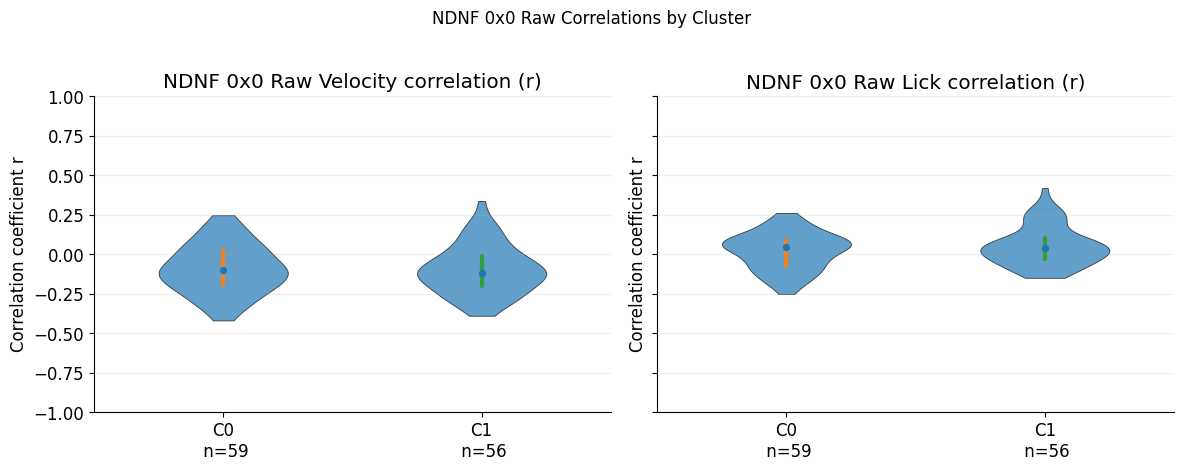

In [244]:
plot_violin_correlations_side_by_side(means_dict_cluster_0x0_raw, num_clusters=2, title="NDNF 0x0 Raw")


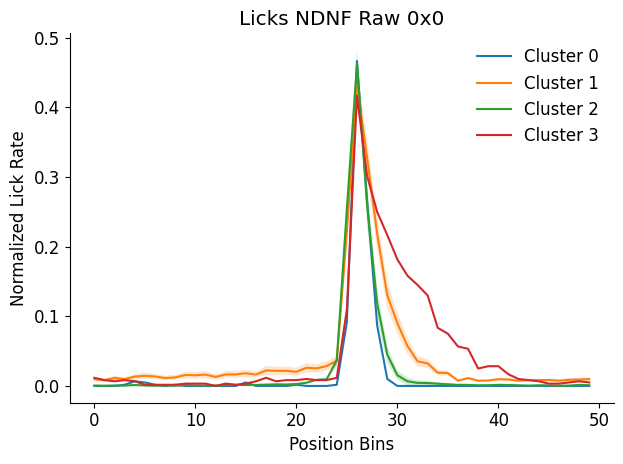

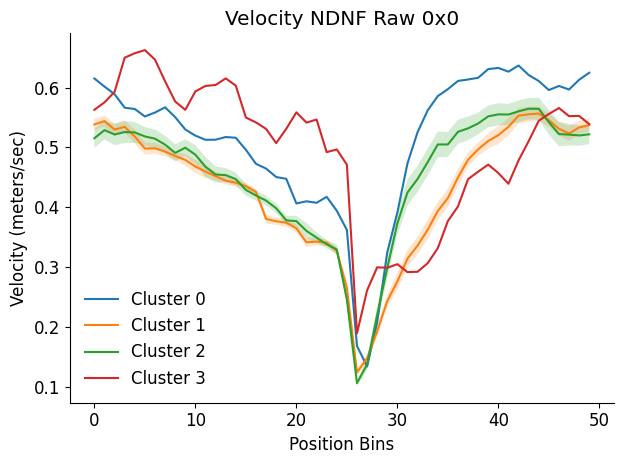

In [167]:
def plot_lick_vel_data_clust(means_dict_cluster_0x0_raw, num_clusters=3, use_vel=False, title=None):

    if use_vel:
        vel_data = means_dict_cluster_0x0_raw[num_clusters]["vel_data_sliced_dict"]
    else:
        vel_data = means_dict_cluster_0x0_raw[num_clusters]["lick_data_sliced_dict"]


    # fig, axs = plt.subplots(1,len(vel_data), figsize=(len(vel_data)*4, 4))
    for clust in vel_data:
        vel_array = vel_data[clust]
        trial_av_vel_array = np.mean(vel_array, axis=2)

        mean_over_cells = np.mean(trial_av_vel_array, axis=0)
        sem_over_cells = sem(trial_av_vel_array, axis=0)

        plt.plot(mean_over_cells, label=f"Cluster {clust}")
        plt.fill_between(range(len(mean_over_cells)), mean_over_cells-sem_over_cells, mean_over_cells+sem_over_cells, alpha=0.2)
        # plt.title(f"Cluster {clust}")
        plt.xlabel("Position Bins")
        if use_vel:
            plt.ylabel(f"Velocity (meters/sec)")
        else:
            plt.ylabel(f"Normalized Lick Rate")
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()


plot_lick_vel_data_clust(means_dict_cluster_0x0_raw, num_clusters=4, use_vel=False, title="Licks NDNF Raw 0x0")
plot_lick_vel_data_clust(means_dict_cluster_0x0_raw, num_clusters=4, use_vel=True, title="Velocity NDNF Raw 0x0")


In [169]:

mse_dir = "/Users/michaelfinch/CA1-interneuron-GLM/datasets/cell_SST_model_ranks20_contig_x00_cells"
cell_SST_model_ranks20_contig_x00 = get_model_data_per_cell(mse_dir)

mse_dir = "/Users/michaelfinch/CA1-interneuron-GLM/datasets/cell_EC_model_ranks20_contig_x00_cells"
cell_EC_model_ranks20_contig_x00 = get_model_data_per_cell(mse_dir)

mse_dir = "/Users/michaelfinch/CA1-interneuron-GLM/datasets/real_final_NDNF_model_ranks20_contig_x00_cell"
cell_NDNF_model_ranks20_contig_x00 = get_model_data_per_cell(mse_dir)

def get_cp_dict(cell_SST_model_ranks20_contig_x00):
    changepoints_dict = {}
    for animal in cell_SST_model_ranks20_contig_x00[20]:
        changepoints_cell_dict = {}
        for cell in cell_SST_model_ranks20_contig_x00[20][animal]:
            labels = cell_SST_model_ranks20_contig_x00[20][animal][cell][1][f'cell_{cell}']["labels_dict"]["clusters_chosen_3"]
            changepoints = np.where(np.diff(labels) != 0)[0]
            changepoints_cell_dict[cell] = changepoints
        changepoints_dict[animal] = changepoints_cell_dict

    return changepoints_dict

def get_fixed_model_dict_NDNF_newest(cell_NDNF_model_ranks20_contig_x00):
    fixed_model_dict_NDNF_newest = {20:{}}
    for animal in cell_NDNF_model_ranks20_contig_x00[20]:
        if 17 < animal < 31:
            fixed_model_dict_NDNF_newest[20][animal-18] = cell_NDNF_model_ranks20_contig_x00[20][animal]
    return fixed_model_dict_NDNF_newest

fixed_model_dict_NDNF_newest = get_fixed_model_dict_NDNF_newest(cell_NDNF_model_ranks20_contig_x00)

cp_dict_EC = get_cp_dict(cell_EC_model_ranks20_contig_x00)
cp_dict_NDNF = get_cp_dict(fixed_model_dict_NDNF_newest)
cp_dict_SST = get_cp_dict(cell_SST_model_ranks20_contig_x00)

Loaded MSEs for 1 rank(s).
  Rank 20:
    Animal 0: 5 cells
    Animal 1: 15 cells
    Animal 2: 6 cells
    Animal 3: 4 cells
    Animal 4: 13 cells
    Animal 5: 13 cells
    Animal 6: 3 cells
    Animal 7: 3 cells
    Animal 8: 3 cells
    Animal 9: 10 cells
Loaded MSEs for 1 rank(s).
  Rank 20:
    Animal 0: 192 cells
    Animal 1: 150 cells
    Animal 2: 154 cells
    Animal 3: 82 cells
    Animal 4: 74 cells
    Animal 5: 64 cells
    Animal 6: 76 cells
Loaded MSEs for 1 rank(s).
  Rank 20:
    Animal 0: 12 cells
    Animal 1: 16 cells
    Animal 2: 4 cells
    Animal 3: 10 cells
    Animal 4: 8 cells
    Animal 5: 7 cells
    Animal 6: 11 cells
    Animal 7: 10 cells
    Animal 8: 17 cells
    Animal 9: 17 cells
    Animal 10: 9 cells
    Animal 11: 6 cells
    Animal 12: 10 cells
    Animal 13: 9 cells
    Animal 14: 6 cells
    Animal 15: 12 cells
    Animal 16: 7 cells
    Animal 17: 7 cells
    Animal 18: 7 cells
    Animal 19: 10 cells
    Animal 20: 9 cells
    Animal 21: 

In [ ]:

def get_activity_cut_learn(fixed_residual_activity_dict_NDNF_newest, cp_dict_NDNF):
    activity_list_early = []
    activity_list_late = []

    for idx, animal in enumerate(fixed_residual_activity_dict_NDNF_newest):
        for idt, cell in enumerate(fixed_residual_activity_dict_NDNF_newest[animal]):
            data = fixed_residual_activity_dict_NDNF_newest[animal][cell]
            cp_early = cp_dict_NDNF[idx][idt][0]
            cp_late = cp_dict_NDNF[idx][idt][0]

            early_data = data[:,:cp_early]
            late_data = data[:,-cp_late:]

            mean_early_data = np.mean(early_data, axis=1)
            activity_list_early.append(mean_early_data)
            mean_late_data = np.mean(late_data, axis=1)
            activity_list_late.append(mean_late_data)




    activity_early_array = np.array(activity_list_early)
    activity_array_late = np.array(activity_list_late)

    return activity_early_array, activity_array_late



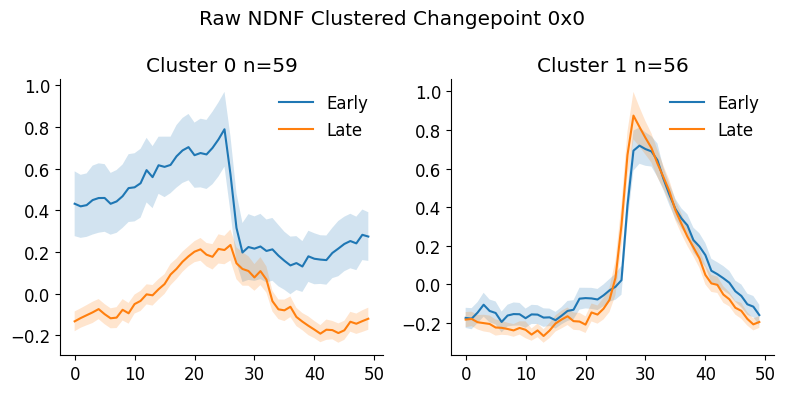

In [207]:

def plot_clustered_data_learn(means_dict_cluster_0x0_raw, activity_early_array, activity_array_late, K=2, title=""):
    data_good = means_dict_cluster_0x0_raw[K]["labels_loc_dict"]

    fig, axs = plt.subplots(1,len(data_good), figsize=(4*len(data_good), 4))
    fig.suptitle(title)

    for i in data_good:
        labels = data_good[i]
        n=len(labels)
        sliced_early = activity_early_array[labels,:]
        mean_sliced_early = np.mean(sliced_early, axis=0)
        sem_sliced_early = sem(sliced_early, axis=0)

        # sliced_data_early_dict[i] = sliced_early
        sliced_late = activity_array_late[labels,:]
        mean_sliced_late = np.mean(sliced_late, axis=0)
        sem_sliced_late = sem(sliced_late, axis=0)

        # sliced_data_late_dict[i] = sliced_late
        axs[i].plot(mean_sliced_early, label='Early')
        axs[i].fill_between(range(len(mean_sliced_early)), mean_sliced_early-sem_sliced_early, mean_sliced_early+sem_sliced_early, alpha=0.2)

        axs[i].plot(mean_sliced_late, label="Late")
        axs[i].fill_between(range(len(mean_sliced_late)), mean_sliced_late-sem_sliced_late, mean_sliced_late+sem_sliced_late, alpha=0.2)
        axs[i].set_title(f"Cluster {i} n={n}")
        axs[i].legend()

    plt.tight_layout()
    plt.show()

activity_early_array, activity_array_late = get_activity_cut_learn(fixed_activity_dict_NDNF_newest, cp_dict_NDNF)
plot_clustered_data_learn(means_dict_cluster_0x0_raw, activity_early_array, activity_array_late, K=2, title="Raw NDNF Clustered Changepoint 0x0")



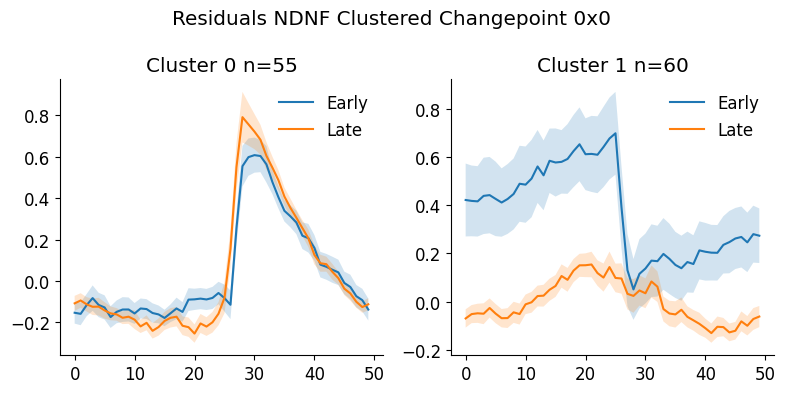

In [209]:
activity_early_array_resid, activity_array_late_resid = get_activity_cut_learn(fixed_residual_activity_dict_NDNF_newest, cp_dict_NDNF)
plot_clustered_data_learn(means_dict_cluster_0x0_resid, activity_early_array_resid, activity_array_late_resid, K=2, title="Residuals NDNF Clustered Changepoint 0x0")

